#Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#Reading Dataset

In [2]:
dataframe=pd.read_csv('/content/synthetic_fraud_dataset1.csv')

#Becoming One With Data

In [3]:
dataframe.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,14 August 2023,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,7 June 2023,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1
2,TXN_199,USER_2734,28.96,Online,20 June 2023,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,7 December 2023,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1
4,TXN_39489,USER_2014,31.28,POS,11 November 2023,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1


In [4]:
dataframe.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label
49995,TXN_11284,USER_4796,45.05,Online,29 January 2023,76960.11,Mobile,Tokyo,Clothing,0,2,Amex,98,0
49996,TXN_44732,USER_1171,126.15,POS,9 May 2023,28791.75,Mobile,Tokyo,Clothing,0,13,Visa,93,1
49997,TXN_38158,USER_2510,72.02,Online,30 January 2023,29916.41,Laptop,Mumbai,Clothing,1,1,Visa,114,0
49998,TXN_860,USER_2248,64.89,Bank Transfer,9 March 2023,67895.67,Mobile,Tokyo,Electronics,0,13,Discover,72,1
49999,TXN_15795,USER_6529,13.00,Bank Transfer,19 August 2023,7668.82,Tablet,London,Restaurants,0,5,Mastercard,154,1


#About DataTypes

In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  object 
 1   User_ID                       50000 non-null  object 
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  object 
 4   Date                          50000 non-null  object 
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  object 
 7   Location                      50000 non-null  object 
 8   Merchant_Category             50000 non-null  object 
 9   Previous_Fraudulent_Activity  50000 non-null  int64  
 10  Daily_Transaction_Count       50000 non-null  int64  
 11  Card_Type                     50000 non-null  object 
 12  Card_Age                      50000 non-null  int64  
 13  F

#Statistical Summary

In [6]:
dataframe.describe()

,Transaction_Amount,Account_Balance,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Age,Fraud_Label
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,99.411012,50294.065981,0.098400,7.485240,119.999940,0.321340
std,98.687292,28760.458557,0.297858,4.039637,68.985817,0.466996
min,0.000000,500.480000,0.000000,1.000000,1.000000,0.000000
25%,28.677500,25355.995000,0.000000,4.000000,60.000000,0.000000
50%,69.660000,50384.430000,0.000000,7.000000,120.000000,0.000000
75%,138.852500,75115.135000,0.000000,11.000000,180.000000,1.000000
max,1174.140000,99998.310000,1.000000,14.000000,239.000000,1.000000


In [7]:
dataframe.shape

(50000, 14)

#Exploratory Data Analysis

##Univariate Analysis

##Determination Of Null Values

In [8]:
dataframe.isnull().sum()

,0
Transaction_ID,0
User_ID,0
Transaction_Amount,0
Transaction_Type,0
Date,0
Account_Balance,0
Device_Type,0
Location,0
Merchant_Category,0
Previous_Fraudulent_Activity,0


##Identification Of Unique Values

In [9]:
for column in dataframe.columns:
    unique_values=dataframe[column].unique()
    print(f"Unique values for column '{column}:")
    print(unique_values)
    print("_"*30)

Unique values for column 'Transaction_ID:
['TXN_33553' 'TXN_9427' 'TXN_199' ... 'TXN_38158' 'TXN_860' 'TXN_15795']
______________________________
Unique values for column 'User_ID:
['USER_1834' 'USER_7875' 'USER_2734' ... 'USER_5657' 'USER_8613'
 'USER_5580']
______________________________
Unique values for column 'Transaction_Amount:
[ 39.79   1.19  28.96 ... 122.76 315.08 109.62]
______________________________
Unique values for column 'Transaction_Type:
['POS' 'Bank Transfer' 'Online' 'ATM Withdrawal']
______________________________
Unique values for column 'Date:
['14 August 2023' '7 June 2023' '20 June 2023' '7 December 2023'
 '11 November 2023' '5 June 2023' '7 November 2023' '25 February 2023'
 '9 March 2023' '20 September 2023' '11 April 2023' '6 August 2023'
 '20 July 2023' '17 November 2023' '3 July 2023' '21 December 2023'
 '8 April 2023' '16 August 2023' '29 April 2023' '28 December 2023'
 '18 June 2023' '11 May 2023' '25 November 2023' '16 July 2023'
 '11 January 2023' '28 

##Visualization of unique values

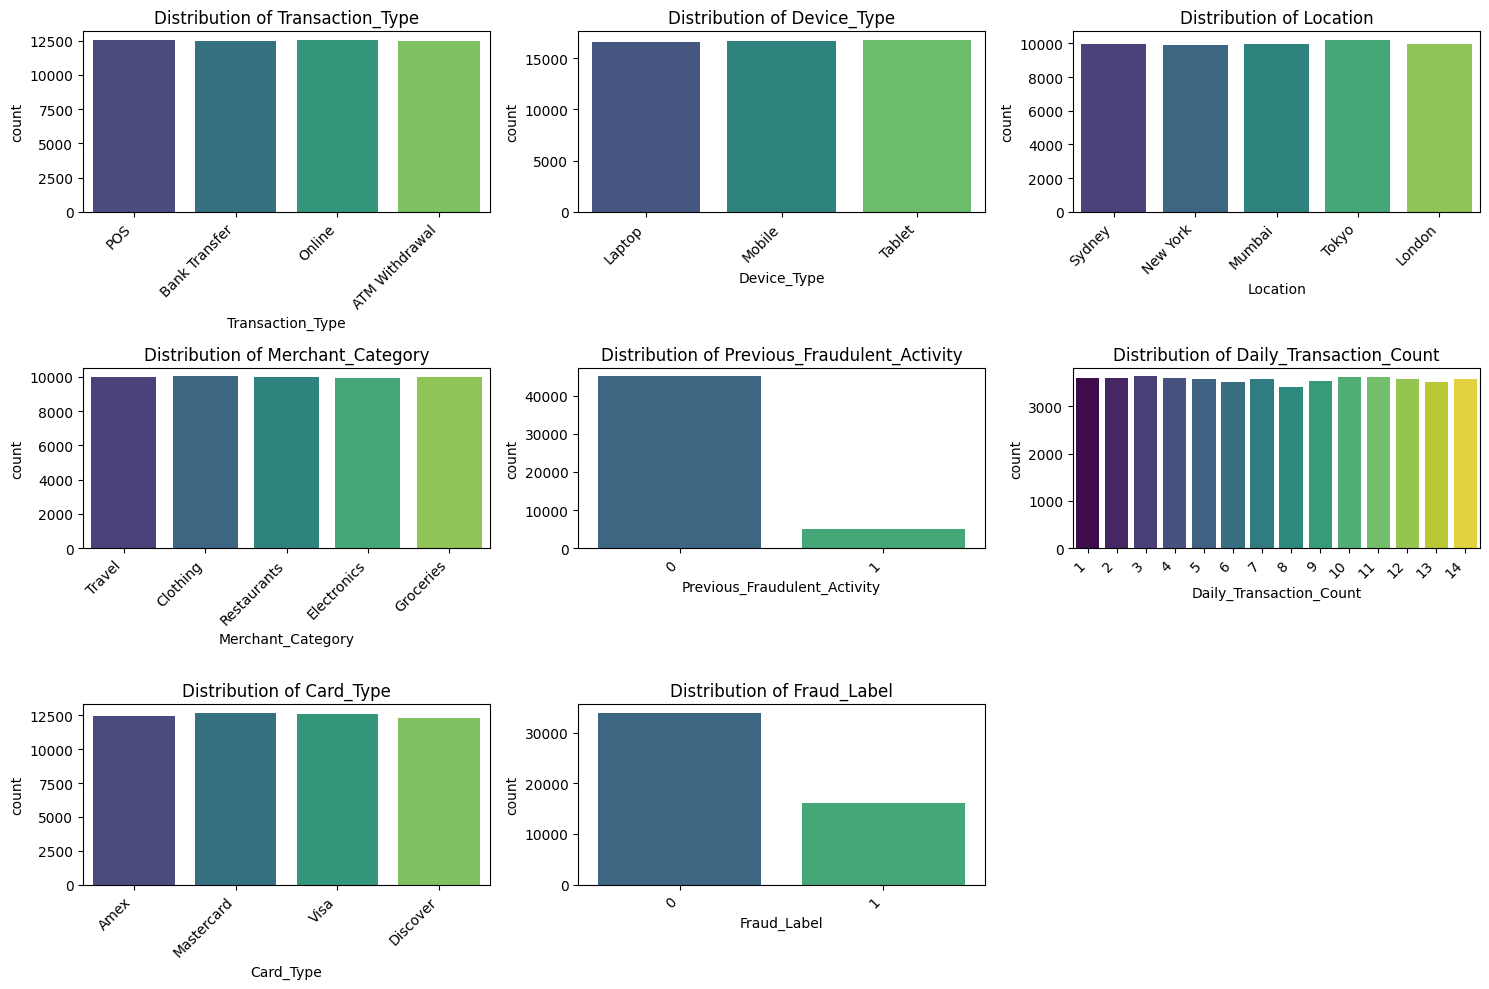

In [10]:
import seaborn as sns

columns_to_visualize = [
    'Transaction_Type',
    'Device_Type',
    'Location',
    'Merchant_Category',
    'Previous_Fraudulent_Activity',
    'Daily_Transaction_Count',
    'Card_Type',
    'Fraud_Label'
]

plt.figure(figsize=(15, 10))
for i, column in enumerate(columns_to_visualize, 1):
    plt.subplot(3, 3, i) # Adjust subplot grid as needed
    sns.countplot(data=dataframe, x=column, hue=column, palette='viridis', legend=False)
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Identification Of Duplicate Values

In [11]:
duplicate_rows = dataframe.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_rows}")

Total number of duplicate rows: 0


#Data Encoding

##Encoding Transaction_Type

In [12]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to 'Transaction_Type'
dataframe['Transaction_Type_Encoded'] = label_encoder.fit_transform(dataframe['Transaction_Type'])

print("Original 'Transaction_Type' column:")
print(dataframe[['Transaction_Type', 'Transaction_Type_Encoded']].head())
print("\nUnique encoded values for 'Transaction_Type':")
print(dataframe['Transaction_Type_Encoded'].unique())

Original 'Transaction_Type' column:
  Transaction_Type  Transaction_Type_Encoded
0              POS                         3
1    Bank Transfer                         1
2           Online                         2
3   ATM Withdrawal                         0
4              POS                         3

Unique encoded values for 'Transaction_Type':
[3 1 2 0]


##Encoding Device_Type

In [13]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to 'Device_Type'
dataframe['Device_Type_Encoded'] = label_encoder.fit_transform(dataframe['Device_Type'])

print("Original 'Device_Type' column:")
print(dataframe[['Device_Type', 'Device_Type_Encoded']].head())
print("\nUnique encoded values for 'Device_Type':")
print(dataframe['Device_Type_Encoded'].unique())

Original 'Device_Type' column:
  Device_Type  Device_Type_Encoded
0      Laptop                    0
1      Mobile                    1
2      Tablet                    2
3      Tablet                    2
4      Mobile                    1

Unique encoded values for 'Device_Type':
[0 1 2]


##Encoding Location

In [14]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to 'Location'
dataframe['Location_Encoded'] = label_encoder.fit_transform(dataframe['Location'])

print("Original 'Location' column:")
print(dataframe[['Location', 'Location_Encoded']].head())
print("\nUnique encoded values for 'Location':")
print(dataframe['Location_Encoded'].unique())

Original 'Location' column:
   Location  Location_Encoded
0    Sydney                 3
1  New York                 2
2    Mumbai                 1
3  New York                 2
4    Mumbai                 1

Unique encoded values for 'Location':
[3 2 1 4 0]


##Encoding Merchant Category

In [15]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to 'Merchant_Category'
dataframe['Merchant_Category_Encoded'] = label_encoder.fit_transform(dataframe['Merchant_Category'])

print("Original 'Merchant_Category' column:")
print(dataframe[['Merchant_Category', 'Merchant_Category_Encoded']].head())
print("\nUnique encoded values for 'Merchant_Category':")
print(dataframe['Merchant_Category_Encoded'].unique())

Original 'Merchant_Category' column:
  Merchant_Category  Merchant_Category_Encoded
0            Travel                          4
1          Clothing                          0
2       Restaurants                          3
3          Clothing                          0
4       Electronics                          1

Unique encoded values for 'Merchant_Category':
[4 0 3 1 2]


In [16]:
dataframe.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Date,Account_Balance,Device_Type,Location,Merchant_Category,Previous_Fraudulent_Activity,Daily_Transaction_Count,Card_Type,Card_Age,Fraud_Label,Transaction_Type_Encoded,Device_Type_Encoded,Location_Encoded,Merchant_Category_Encoded
0,TXN_33553,USER_1834,39.79,POS,14 August 2023,93213.17,Laptop,Sydney,Travel,0,7,Amex,65,0,3,0,3,4
1,TXN_9427,USER_7875,1.19,Bank Transfer,7 June 2023,75725.25,Mobile,New York,Clothing,0,13,Mastercard,186,1,1,1,2,0
2,TXN_199,USER_2734,28.96,Online,20 June 2023,1588.96,Tablet,Mumbai,Restaurants,0,14,Visa,226,1,2,2,1,3
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,7 December 2023,76807.20,Tablet,New York,Clothing,0,8,Visa,76,1,0,2,2,0
4,TXN_39489,USER_2014,31.28,POS,11 November 2023,92354.66,Mobile,Mumbai,Electronics,1,14,Mastercard,140,1,3,1,1,1


#Probability Distribution

--- Probability Distribution of Numerical Features ---


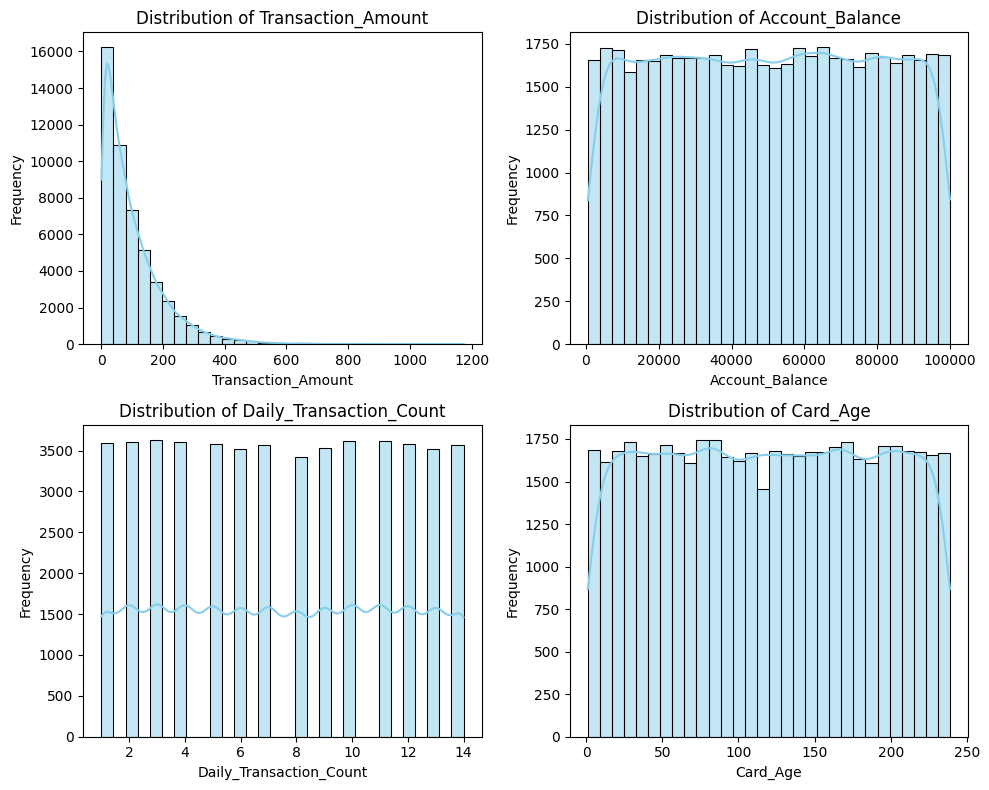


--- Probability Distribution of Categorical Features ---


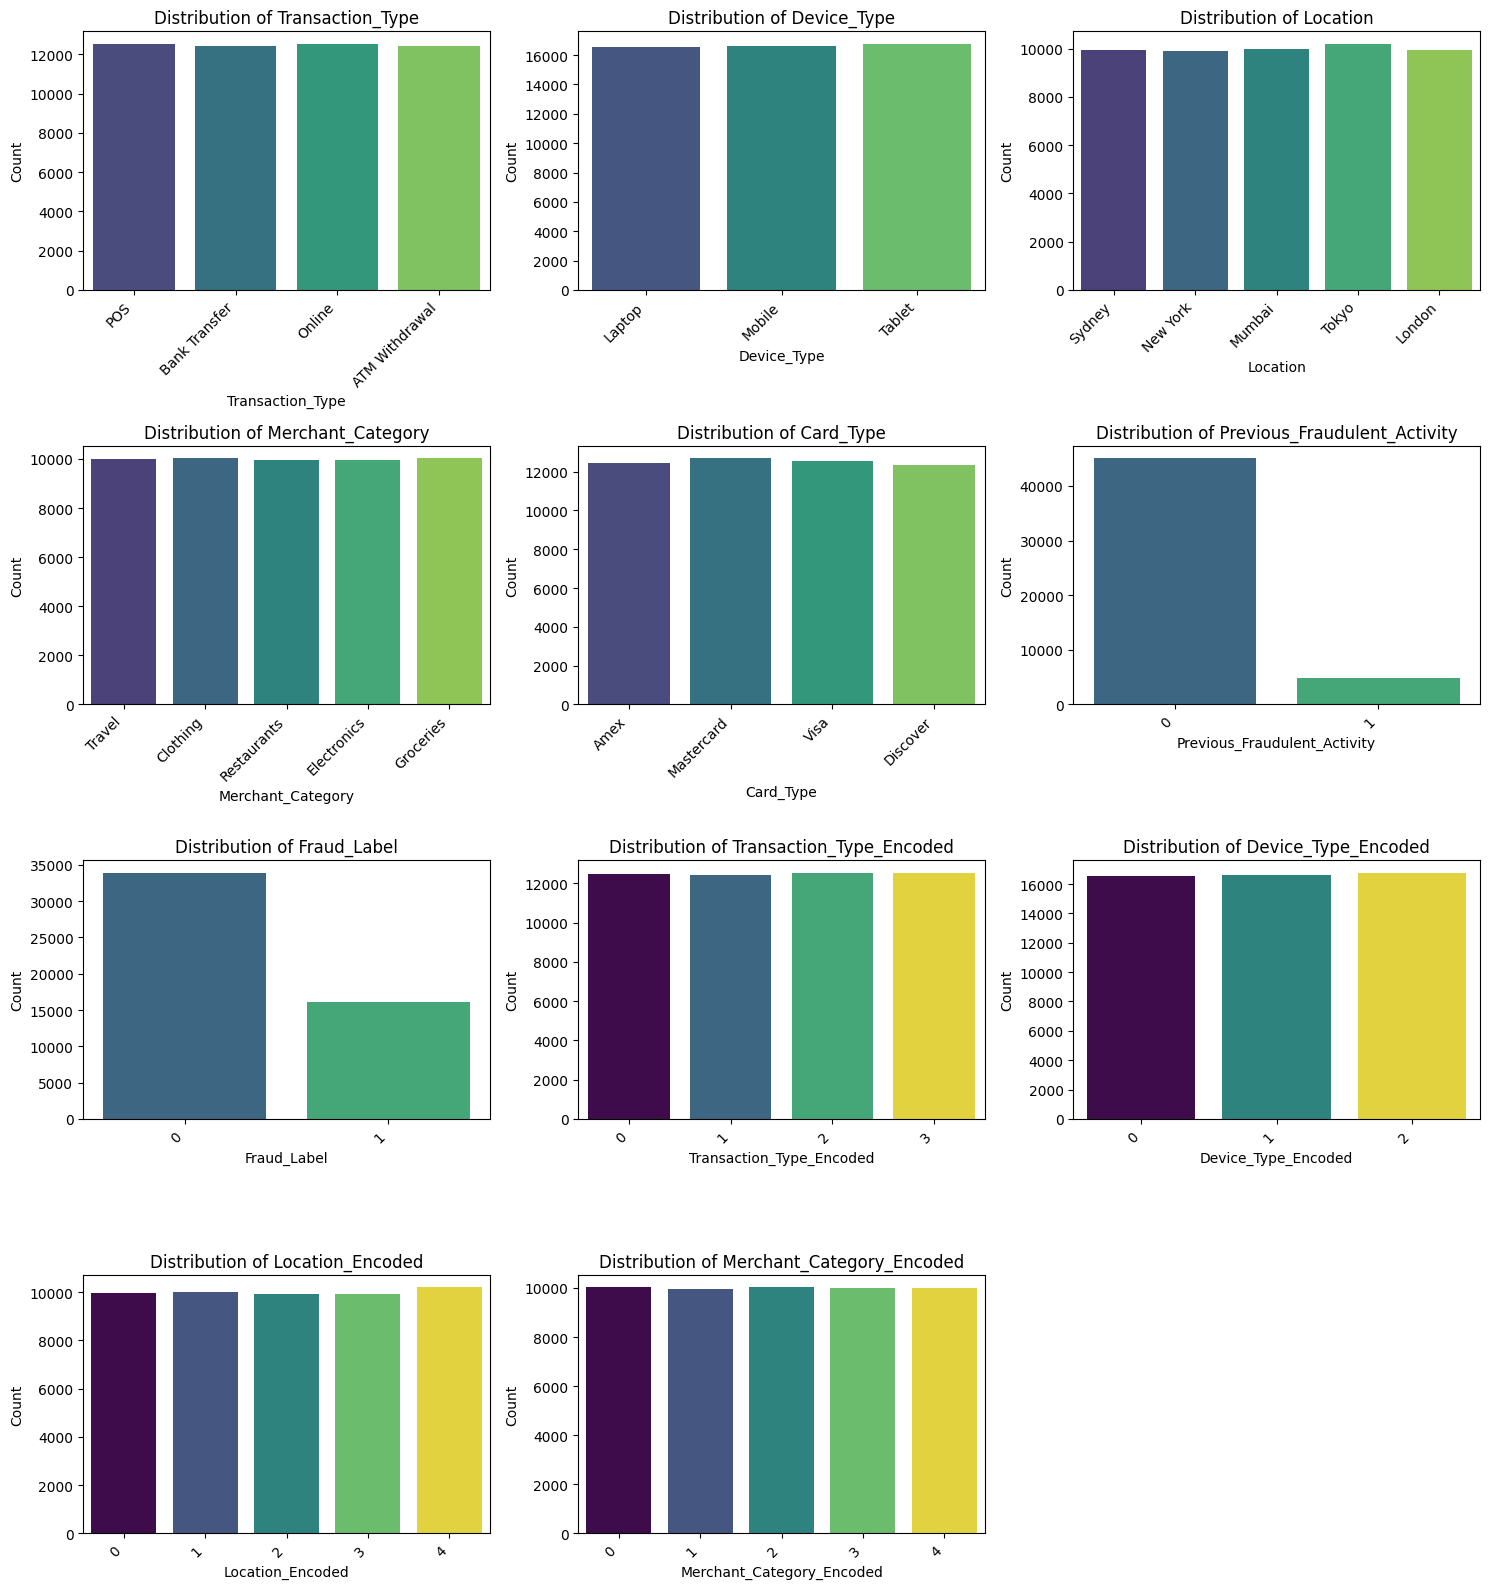

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical and categorical columns for distribution plots
# Exclude ID columns and raw 'Date' which would need specialized handling for distribution
numerical_cols = [
    'Transaction_Amount',
    'Account_Balance',
    'Daily_Transaction_Count',
    'Card_Age'
]

categorical_cols = [
    'Transaction_Type',
    'Device_Type',
    'Location',
    'Merchant_Category',
    'Card_Type',
    'Previous_Fraudulent_Activity',
    'Fraud_Label',
    'Transaction_Type_Encoded',
    'Device_Type_Encoded',
    'Location_Encoded',
    'Merchant_Category_Encoded'
]

# Plotting numerical distributions (histograms and KDE)
print("--- Probability Distribution of Numerical Features ---")
plt.figure(figsize=(10, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i) # Adjust grid size as needed
    sns.histplot(dataframe[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plotting categorical distributions (countplots)
print("\n--- Probability Distribution of Categorical Features ---")
# Calculate number of rows and columns for categorical plots
num_cat_plots = len(categorical_cols)
num_cols_cat = 3 # Number of columns for categorical plots
num_rows_cat = (num_cat_plots + num_cols_cat - 1) // num_cols_cat

plt.figure(figsize=(num_cols_cat * 5, num_rows_cat * 4))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(num_rows_cat, num_cols_cat, i)
    # Check if column exists before plotting
    if col in dataframe.columns:
        sns.countplot(data=dataframe, x=col, hue=col, palette='viridis', legend=False)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
    else:
        print(f"Column '{col}' not found in DataFrame. Skipping plot.")
plt.tight_layout()
plt.show()

#Identification Of Outliers

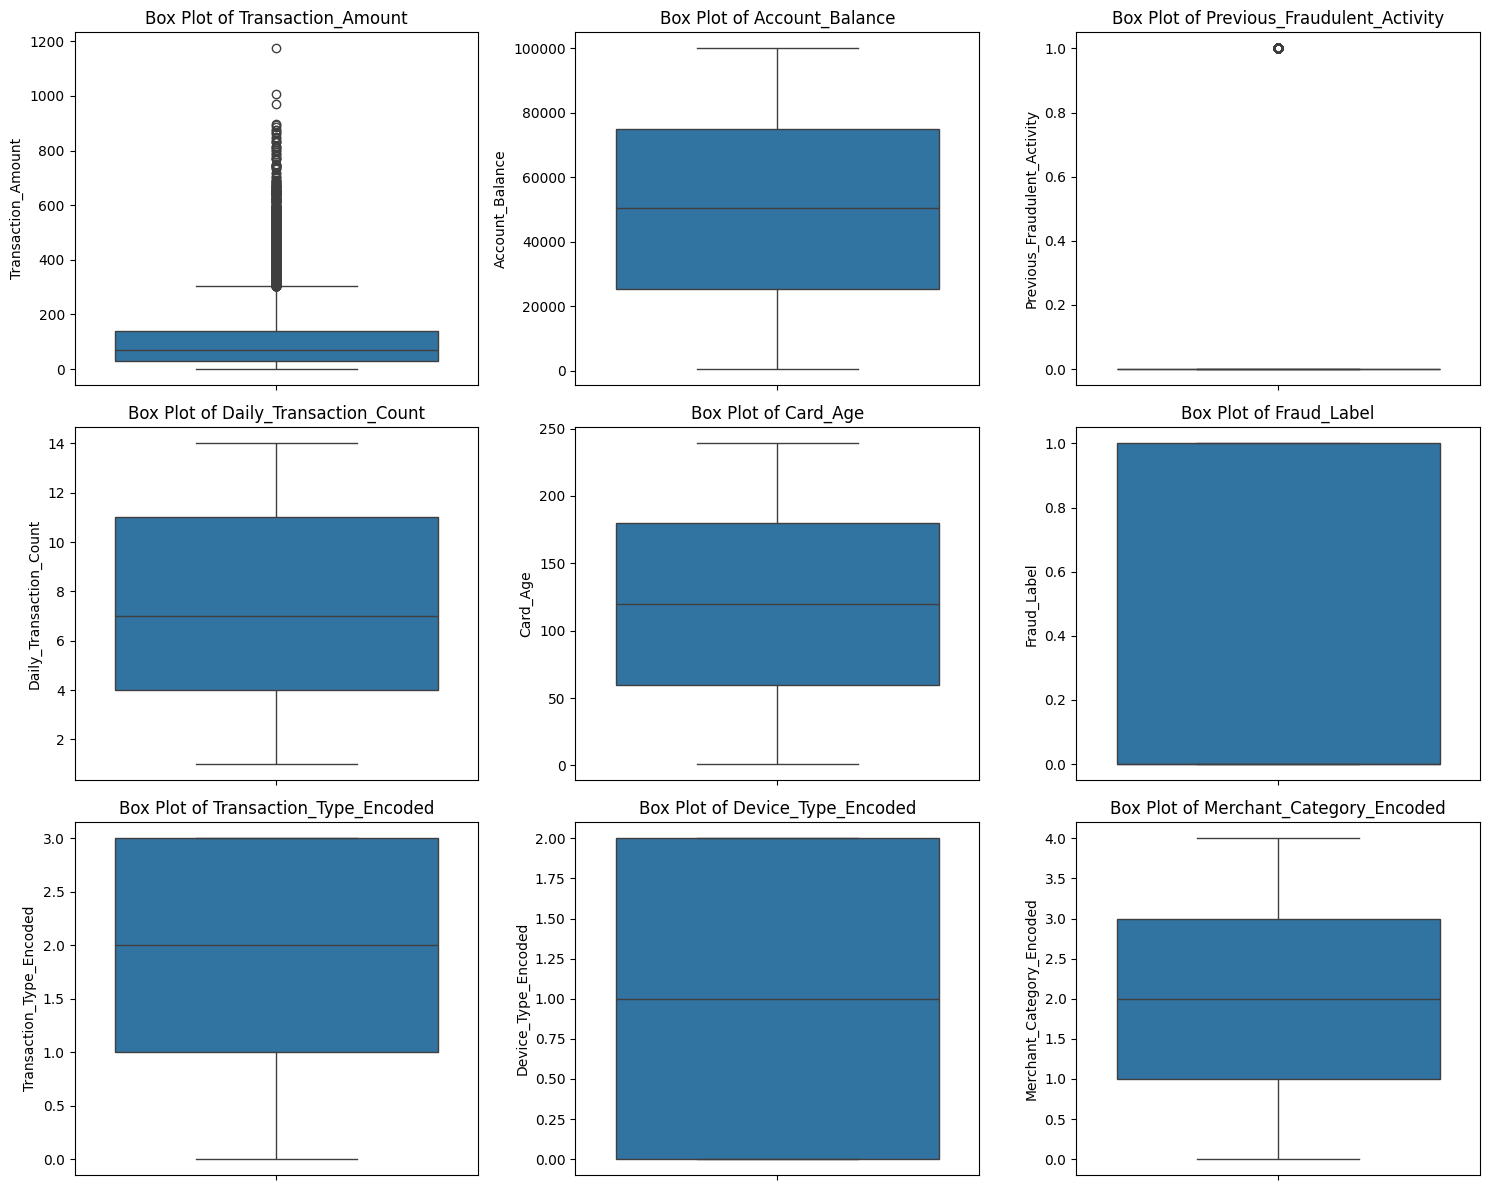

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

columns_to_boxplot = [
    'Transaction_Amount',
    'Account_Balance',
    'Previous_Fraudulent_Activity',
    'Daily_Transaction_Count',
    'Card_Age',
    'Fraud_Label',
    'Transaction_Type_Encoded',
    'Device_Type_Encoded',
    'Merchant_Category_Encoded' # Assuming 'Card_type_encodd' was a typo
]

# Calculate number of rows and columns for subplots
num_plots = len(columns_to_boxplot)
num_cols = 3 # You can adjust this based on desired layout
num_rows = (num_plots + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 5, num_rows * 4))
for i, column in enumerate(columns_to_boxplot, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.boxplot(y=dataframe[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

In [19]:
# Outlier removal for 'Transaction_Amount' using IQR method
Q1 = dataframe['Transaction_Amount'].quantile(0.25)
Q3 = dataframe['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Get the number of outliers before removal
outliers_before = dataframe[(dataframe['Transaction_Amount'] < lower_bound) | (dataframe['Transaction_Amount'] > upper_bound)].shape[0]

# Remove outliers
dataframe_no_outliers = dataframe[(dataframe['Transaction_Amount'] >= lower_bound) & (dataframe['Transaction_Amount'] <= upper_bound)]

print(f"Original number of rows: {dataframe.shape[0]}")
print(f"Number of outliers removed from 'Transaction_Amount': {outliers_before}")
print(f"Number of rows after outlier removal: {dataframe_no_outliers.shape[0]}")

# Update the original dataframe or work with dataframe_no_outliers
dataframe = dataframe_no_outliers.copy()

print("\n'Previous_Fraudulent_Activity' is a binary column (0 or 1) and does not have outliers in the traditional sense of continuous data.")
print("Unique values for 'Previous_Fraudulent_Activity':", dataframe['Previous_Fraudulent_Activity'].unique())

Original number of rows: 50000
Number of outliers removed from 'Transaction_Amount': 2260
Number of rows after outlier removal: 47740

'Previous_Fraudulent_Activity' is a binary column (0 or 1) and does not have outliers in the traditional sense of continuous data.
Unique values for 'Previous_Fraudulent_Activity': [0 1]


#Class Balancing

Distribution of 'Fraud_Label' column:
Fraud_Label
0    32407
1    15333
Name: count, dtype: int64


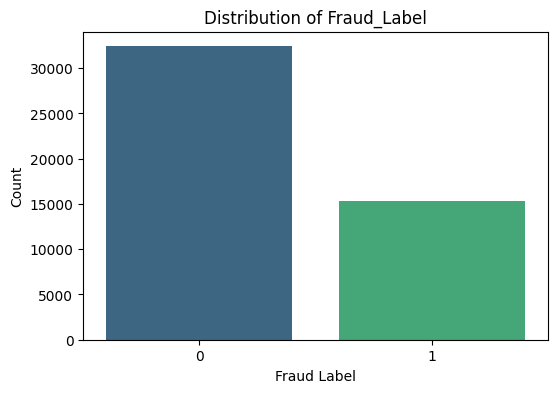

In [20]:
print("Distribution of 'Fraud_Label' column:")
print(dataframe['Fraud_Label'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Fraud_Label', data=dataframe, hue='Fraud_Label', palette='viridis', legend=False)
plt.title('Distribution of Fraud_Label')
plt.xlabel('Fraud Label')
plt.ylabel('Count')
plt.show()

##Implementation Of Smote Technique

In [21]:
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X = dataframe.drop(columns=['Fraud_Label', 'Transaction_ID', 'User_ID', 'Transaction_Type', 'Date', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type'])
y = dataframe['Fraud_Label']

# Drop rows where 'Fraud_Label' (y) is NaN
# This ensures that SMOTE does not encounter missing values in the target variable
# Aligning X and y after dropping NaNs
not_nan_indices = y.dropna().index
X = X.loc[not_nan_indices]
y = y.loc[not_nan_indices]

print(f"Shape of X before SMOTE: {X.shape}")
print(f"Shape of y before SMOTE: {y.shape}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Shape of X after SMOTE: {X_resampled.shape}")
print(f"Shape of y after SMOTE: {y_resampled.shape}")

Shape of X before SMOTE: (47740, 9)
Shape of y before SMOTE: (47740,)
Shape of X after SMOTE: (64814, 9)
Shape of y after SMOTE: (64814,)


##Visualization After Class Balancing

Distribution of 'Fraud_Label' column after SMOTE:
Fraud_Label
0    32407
1    32407
Name: count, dtype: int64


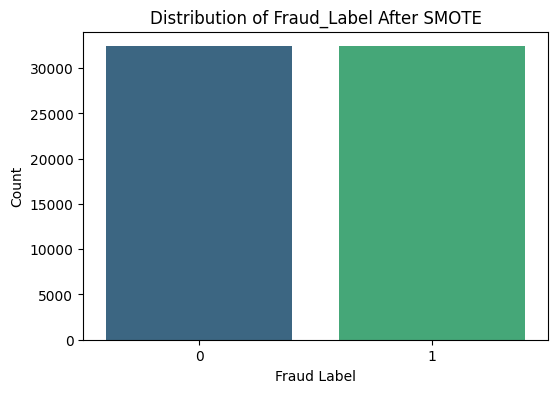

In [22]:
print("Distribution of 'Fraud_Label' column after SMOTE:")
print(y_resampled.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_resampled, hue=y_resampled, palette='viridis', legend=False)
plt.title('Distribution of Fraud_Label After SMOTE')
plt.xlabel('Fraud Label')
plt.ylabel('Count')
plt.show()

#Behavioual Pattern Analytics

##Transaction Amount

###Average Transaction Amount

In [23]:
average_transaction_amount = dataframe['Transaction_Amount'].mean()
print(f"Average transaction amount for the entire dataset: ${average_transaction_amount:.2f}")

Average transaction amount for the entire dataset: $85.01


###Highest Transaction Amount

In [24]:
highest_transaction_amount = dataframe['Transaction_Amount'].max()
print(f"Highest transaction amount: ${highest_transaction_amount:.2f}")

Highest transaction amount: $304.04


###Lowest Transaction Amount

In [25]:
lowest_transaction_amount = dataframe['Transaction_Amount'].min()
print(f"Lowest transaction amount: ${lowest_transaction_amount:.2f}")

Lowest transaction amount: $0.00


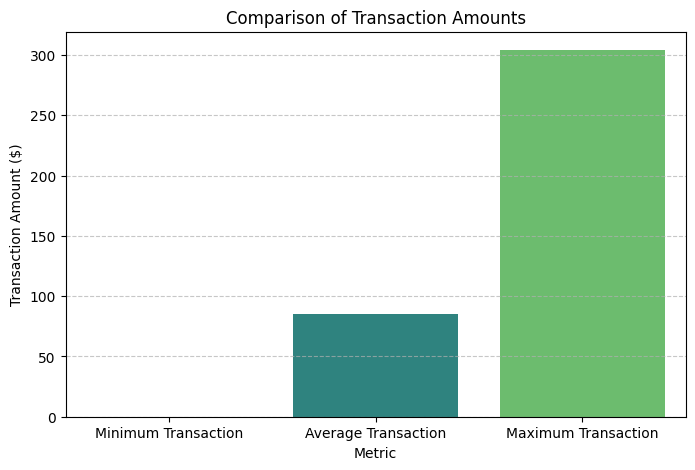

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
transaction_data = {
    'Metric': ['Minimum Transaction', 'Average Transaction', 'Maximum Transaction'],
    'Value': [lowest_transaction_amount, average_transaction_amount, highest_transaction_amount]
}

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Value', data=transaction_data, hue='Metric', palette='viridis', legend=False)
plt.title('Comparison of Transaction Amounts')
plt.ylabel('Transaction Amount ($)')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##Account Balance

In [27]:
minimum_account_balance = dataframe['Account_Balance'].min()
print(f"Minimum account balance: ${minimum_account_balance:.2f}")

Minimum account balance: $500.48


In [28]:
maximum_account_balance = dataframe['Account_Balance'].max()
print(f"Maximum account balance: ${maximum_account_balance:.2f}")

Maximum account balance: $99998.31


In [29]:
average_account_balance = dataframe['Account_Balance'].mean()
print(f"Average account balance: ${average_account_balance:.2f}")

Average account balance: $50323.59


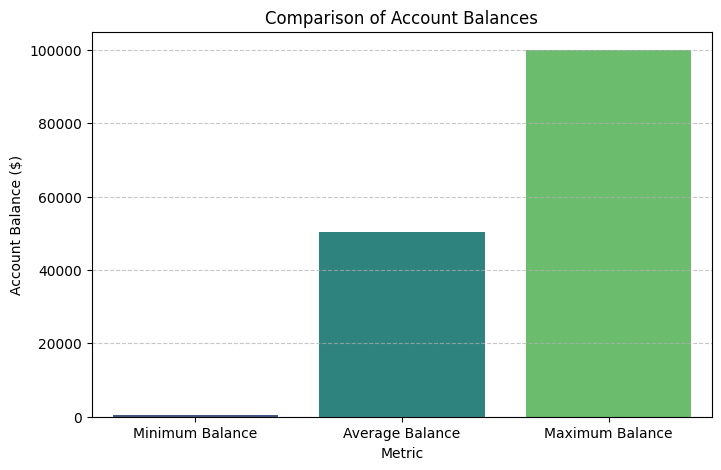

In [30]:
# A pie chart is not suitable for visualizing max, min, and average values
# as they are not parts of a whole. A bar chart or a simple table is more appropriate.

# Existing values:
# minimum_account_balance: $500.48
# maximum_account_balance: $99998.31
# average_account_balance: $50323.59

# Example of how to visualize them with a bar chart (more appropriate):
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dictionary or list for plotting
balance_data = {
    'Metric': ['Minimum Balance', 'Average Balance', 'Maximum Balance'],
    'Value': [minimum_account_balance, average_account_balance, maximum_account_balance]
}

plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Value', data=balance_data, hue='Metric', palette='viridis', legend=False) # Fix for FutureWarning
plt.title('Comparison of Account Balances')
plt.ylabel('Account Balance ($)')
plt.xlabel('Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##Transaction Type

In [31]:
most_common_transaction_type = dataframe['Transaction_Type'].value_counts().idxmax()
print(f"The most common transaction type is: {most_common_transaction_type}")

The most common transaction type is: POS


In [32]:
least_common_transaction_type = dataframe['Transaction_Type'].value_counts().idxmin()
print(f"The least common transaction type is: {least_common_transaction_type}")

The least common transaction type is: ATM Withdrawal


##Device Type

In [33]:
most_common_device_type = dataframe['Device_Type'].value_counts().idxmax()
print(f"The most common device type used is: {most_common_device_type}")

The most common device type used is: Tablet


In [34]:
least_common_device_type = dataframe['Device_Type'].value_counts().idxmin()
print(f"The least common device type used is: {least_common_device_type}")

The least common device type used is: Laptop


##Locations

In [35]:
highest_transaction_location = dataframe.loc[dataframe['Transaction_Amount'] == highest_transaction_amount, 'Location'].unique()
print(f"Location(s) where the highest transaction amount (${highest_transaction_amount:.2f}) was done: {highest_transaction_location}")

Location(s) where the highest transaction amount ($304.04) was done: ['London']


In [36]:
most_transactions_location = dataframe['Location'].value_counts().idxmax()
print(f"The location with the most transactions is: {most_transactions_location}")

The location with the most transactions is: Tokyo


In [37]:
least_transactions_location = dataframe['Location'].value_counts().idxmin()
print(f"The location with the least transactions is: {least_transactions_location}")

The location with the least transactions is: New York


##Merchant Category

In [38]:
most_common_merchant_category = dataframe['Merchant_Category'].value_counts().idxmax()
print(f"The most common merchant category is: {most_common_merchant_category}")

The most common merchant category is: Travel


In [39]:
least_common_merchant_category = dataframe['Merchant_Category'].value_counts().idxmin()
print(f"The least common merchant category is: {least_common_merchant_category}")

The least common merchant category is: Restaurants


##Card Type

In [40]:
most_common_card_type = dataframe['Card_Type'].value_counts().idxmax()
print(f"The most common card type is: {most_common_card_type}")

The most common card type is: Mastercard


In [41]:
least_common_card_type = dataframe['Card_Type'].value_counts().idxmin()
print(f"The least common card type is: {least_common_card_type}")

The least common card type is: Discover


#Bivariate Analysis

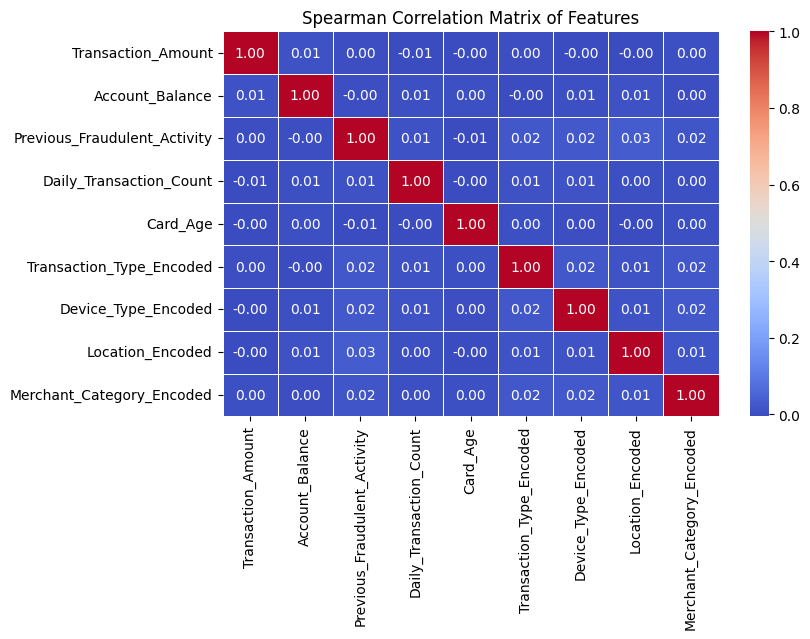

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the Spearman correlation matrix
spearman_correlation_matrix = X_resampled.corr(method='spearman')

plt.figure(figsize=(8, 5))
sns.heatmap(spearman_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Spearman Correlation Matrix of Features')
plt.show()

#Multivariate Analysis

##Pair Plot

<Figure size 1500x1500 with 0 Axes>

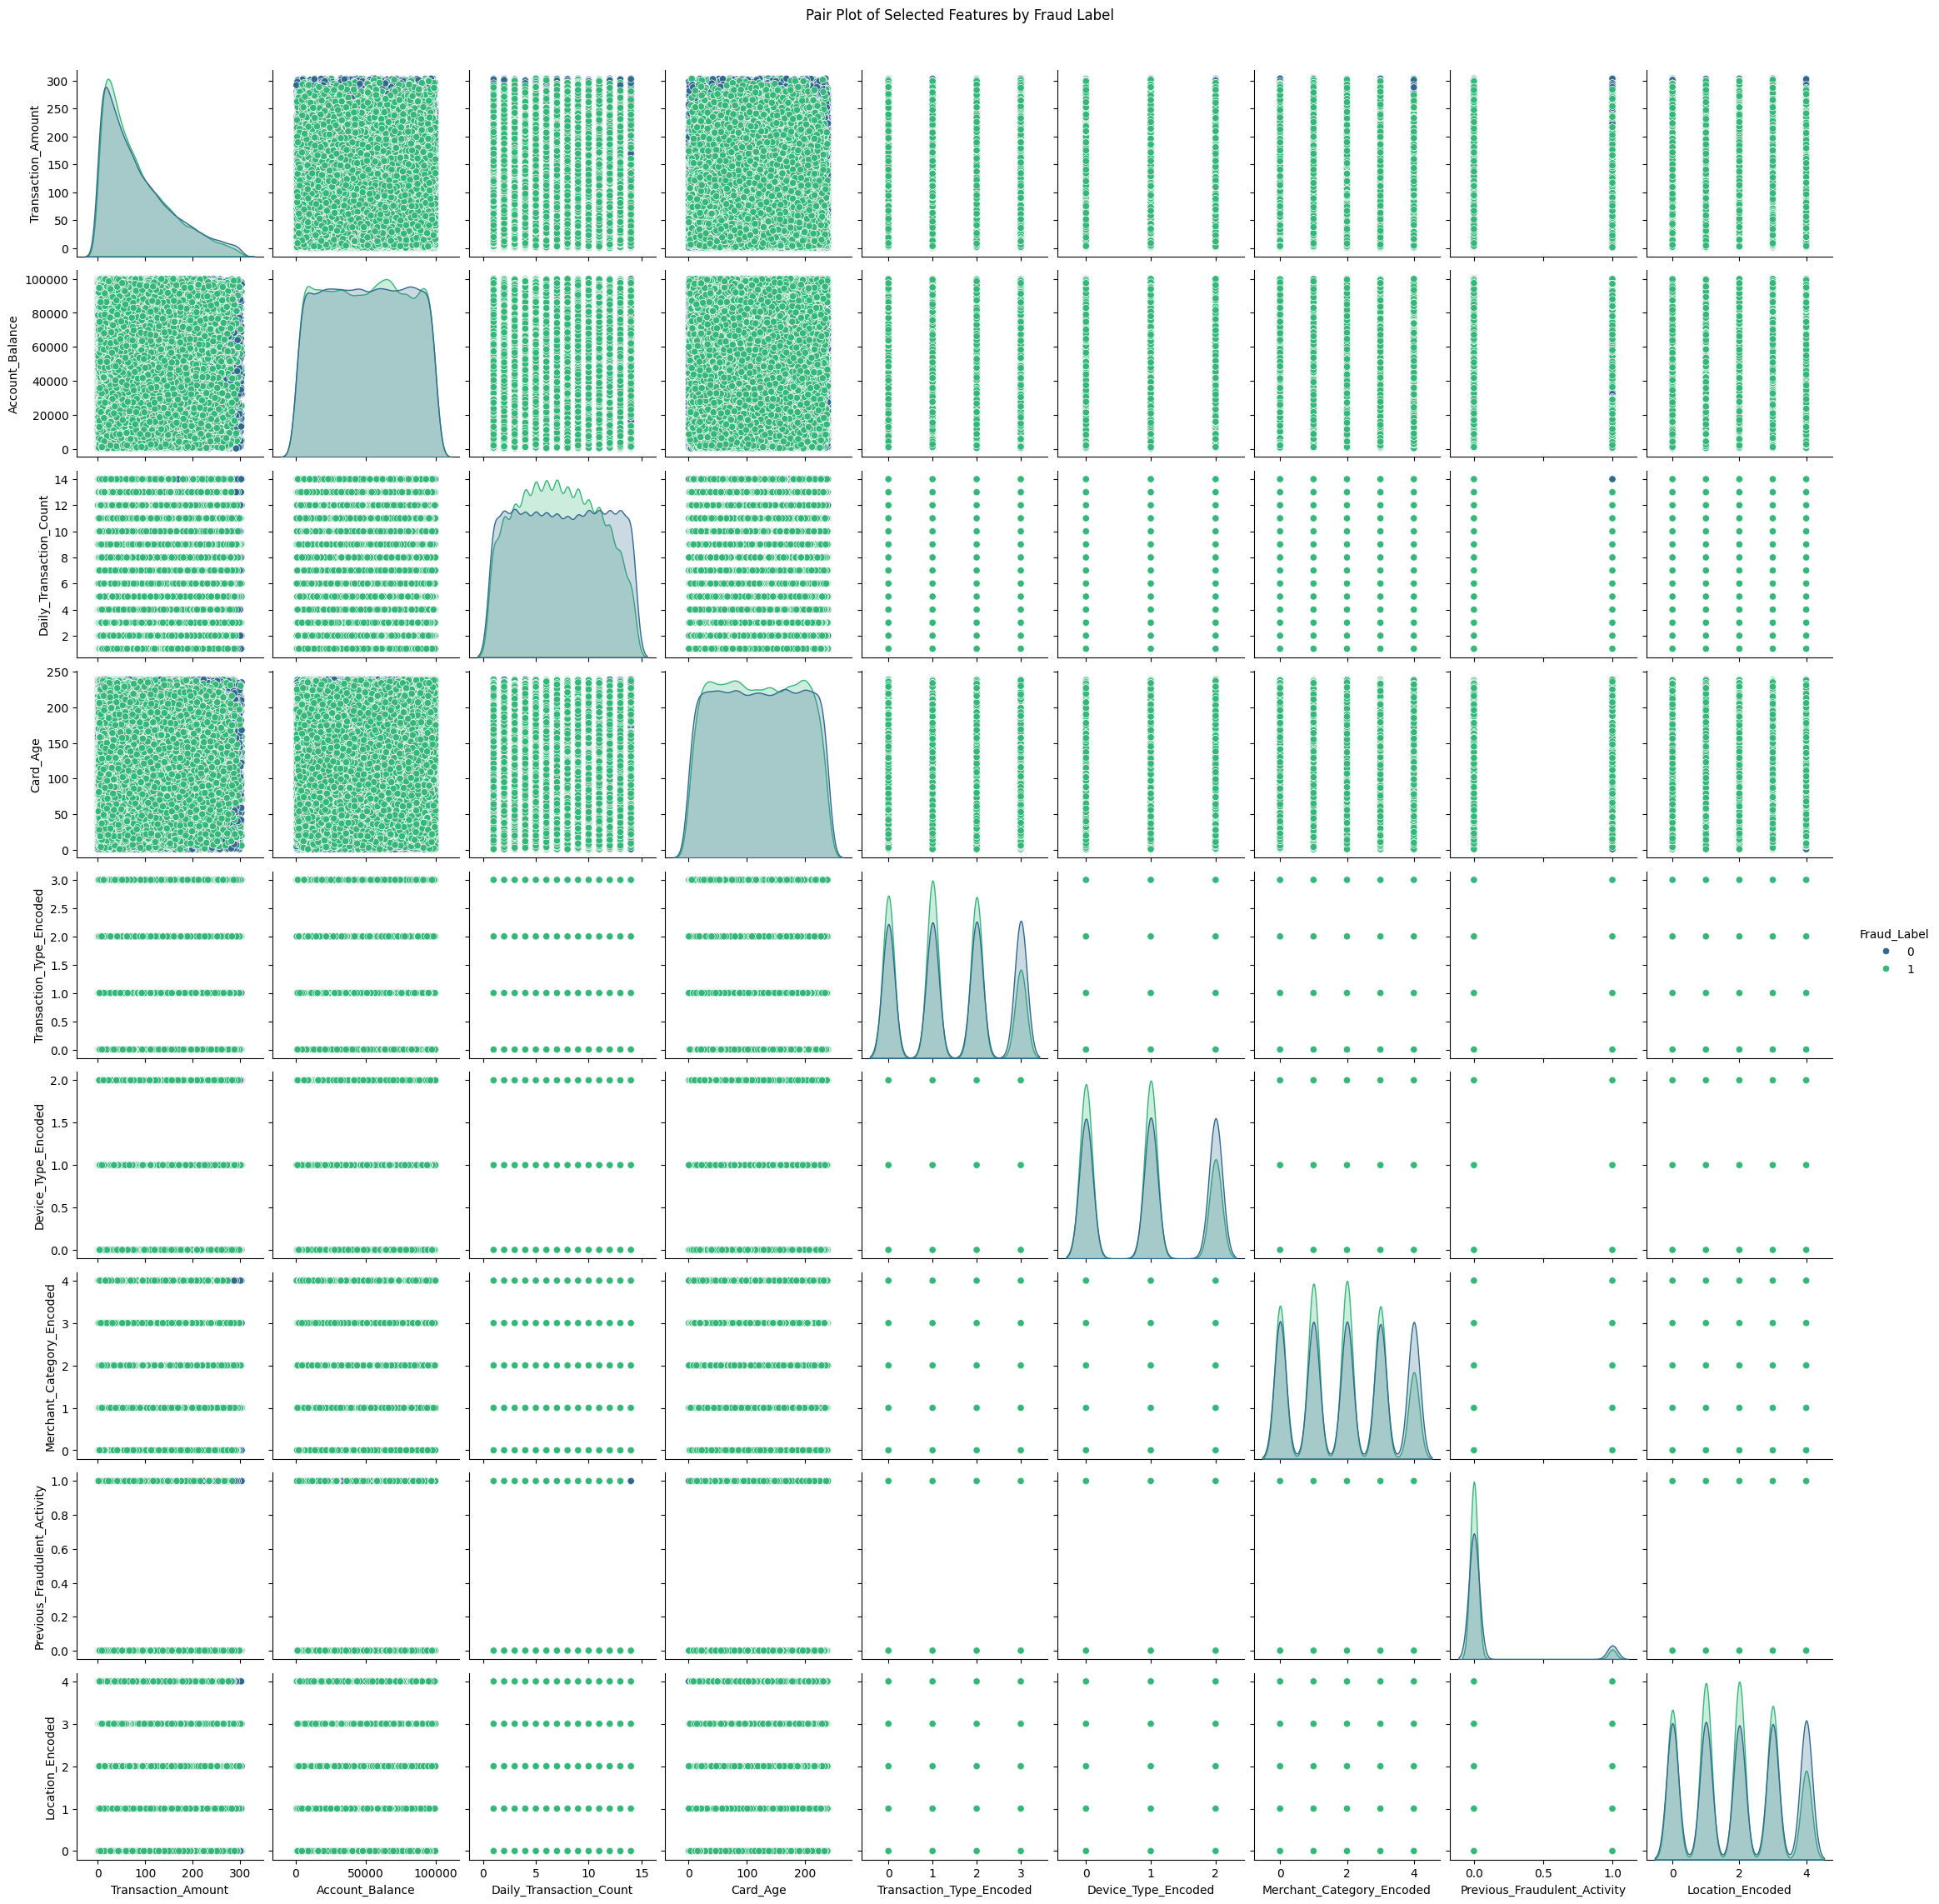

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine X_resampled and y_resampled for a comprehensive pair plot
# Select a subset of features for better readability, as plotting all 9 features + target can be too dense
features_for_pairplot = [
    'Transaction_Amount',
    'Account_Balance',
    'Daily_Transaction_Count',
    'Card_Age',
    'Transaction_Type_Encoded',
    'Device_Type_Encoded',
    'Merchant_Category_Encoded',
    'Previous_Fraudulent_Activity',
    'Location_Encoded'
]

# Create a temporary DataFrame for pair plot including selected features and the target variable
df_pairplot = X_resampled[features_for_pairplot].copy()
df_pairplot['Fraud_Label'] = y_resampled.reset_index(drop=True) # Ensure index alignment

# Generate the pair plot
# 'hue' allows us to differentiate between Fraud and Non-Fraud cases
plt.figure(figsize=(15, 15)) # Adjust figure size as needed, though seaborn auto-adjusts
sns.pairplot(df_pairplot, hue='Fraud_Label', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Features by Fraud Label', y=1.02) # Adjust suptitle position
plt.show()

#Standardization And Normalization

In [44]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# --- Standardization (StandardScaler) ---
# Initializes the StandardScaler
scaler = StandardScaler()

# Fits the scaler to the training data and transforms it
X_standardized = scaler.fit_transform(X_resampled)

# Converts the standardized array back to a DataFrame for better readability
X_standardized = pd.DataFrame(X_standardized, columns=X_resampled.columns)

print("--- Data after Standardization (StandardScaler) ---")
print(X_standardized.head())
print("\n")

# --- Normalization (MinMaxScaler) ---
# Initializes the MinMaxScaler
min_max_scaler = MinMaxScaler()

# Fits the scaler to the training data and transforms it
X_normalized = min_max_scaler.fit_transform(X_resampled)

--- Data after Standardization (StandardScaler) ---
   Transaction_Amount  Account_Balance  Previous_Fraudulent_Activity  \
0           -0.632451         1.492188                     -0.284682   
1           -1.184467         0.884373                     -0.284682   
2           -0.787330        -1.692329                     -0.284682   
3            2.435526         0.921977                     -0.284682   
4           -0.754152         1.462349                      3.512685   

   Daily_Transaction_Count  Card_Age  Transaction_Type_Encoded  \
0                -0.086654 -0.803986                  1.478435   
1                 1.464904  0.977328                 -0.374064   
2                 1.723497  1.566192                  0.552185   
3                 0.171939 -0.642049                 -1.300313   
4                 1.723497  0.300134                  1.478435   

   Device_Type_Encoded  Location_Encoded  Merchant_Category_Encoded  
0            -1.156883          0.802947        

#Machine Learning Modelling

##Logistic Regression

X_train shape: (48610, 9)
X_test shape: (16204, 9)
y_train shape: (48610,)
y_test shape: (16204,)

--- Original Logistic Regression Model on Normalized Data ---

Accuracy: 0.5926

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.57      0.58      8088
           1       0.59      0.61      0.60      8116

    accuracy                           0.59     16204
   macro avg       0.59      0.59      0.59     16204
weighted avg       0.59      0.59      0.59     16204



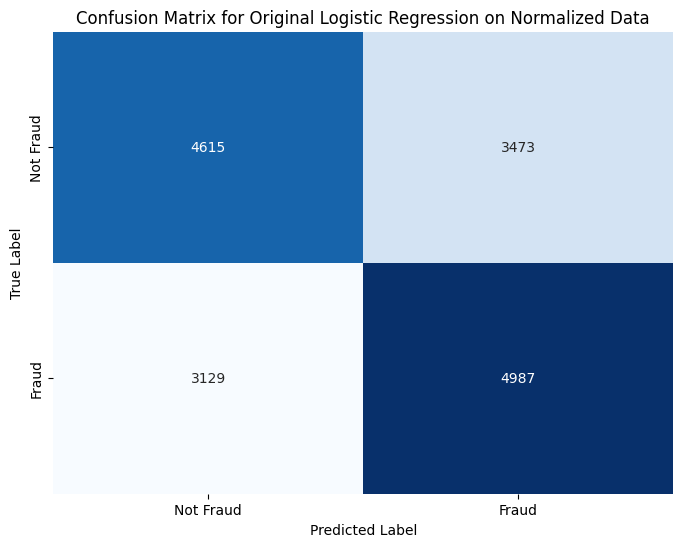


--- Logistic Regression with L1 Regularization on Normalized Data ---

L1 Regularization Accuracy: 0.5927

L1 Regularization Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.57      0.58      8088
           1       0.59      0.61      0.60      8116

    accuracy                           0.59     16204
   macro avg       0.59      0.59      0.59     16204
weighted avg       0.59      0.59      0.59     16204



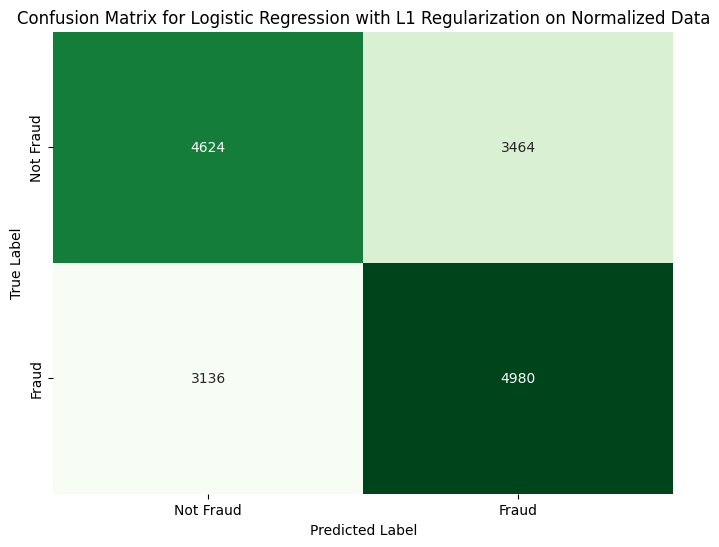


--- Logistic Regression with L2 Regularization on Normalized Data ---

L2 Regularization Accuracy: 0.5929

L2 Regularization Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.57      0.58      8088
           1       0.59      0.61      0.60      8116

    accuracy                           0.59     16204
   macro avg       0.59      0.59      0.59     16204
weighted avg       0.59      0.59      0.59     16204



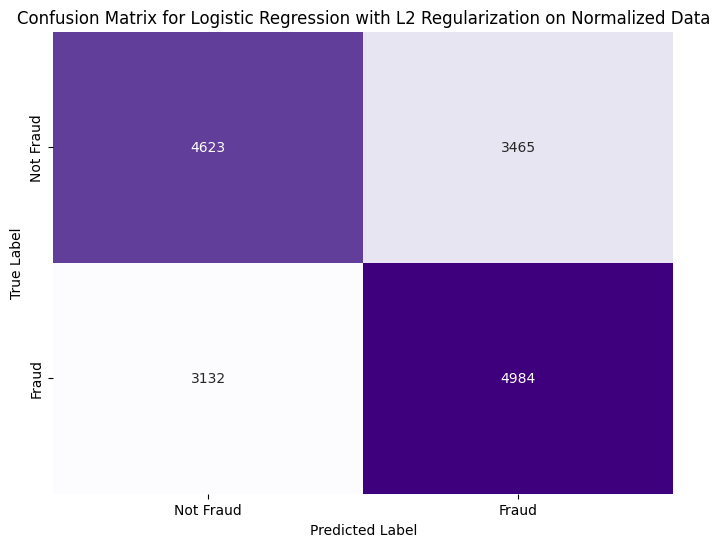

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split the normalized data into training and testing sets
# Using X_normalized instead of X_resampled
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.25, random_state=50)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# --- Original Logistic Regression Model ---
print("\n--- Original Logistic Regression Model on Normalized Data ---")
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=50, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
logistic_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = logistic_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Original Logistic Regression on Normalized Data')
plt.show()

# --- Logistic Regression with L1 Regularization ---
print("\n--- Logistic Regression with L1 Regularization on Normalized Data ---")
# L1 regularization (Lasso) promotes sparsity (some coefficients become zero)
# C is the inverse of regularization strength; smaller C implies stronger regularization
logistic_l1_model = LogisticRegression(penalty='l1', C=0.1, random_state=50, solver='liblinear')
logistic_l1_model.fit(X_train, y_train)

y_pred_l1 = logistic_l1_model.predict(X_test)

accuracy_l1 = accuracy_score(y_test, y_pred_l1)
print(f"\nL1 Regularization Accuracy: {accuracy_l1:.4f}")

print("\nL1 Regularization Classification Report:")
print(classification_report(y_test, y_pred_l1))

conf_matrix_l1 = confusion_matrix(y_test, y_pred_l1)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_l1, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression with L1 Regularization on Normalized Data')
plt.show()

# --- Logistic Regression with L2 Regularization ---
print("\n--- Logistic Regression with L2 Regularization on Normalized Data ---")
# L2 regularization (Ridge) shrinks coefficients towards zero but doesn't make them exactly zero
# C is the inverse of regularization strength; smaller C implies stronger regularization
logistic_l2_model = LogisticRegression(penalty='l2', C=0.1, random_state=50, solver='liblinear')
logistic_l2_model.fit(X_train, y_train)

y_pred_l2 = logistic_l2_model.predict(X_test)

accuracy_l2 = accuracy_score(y_test, y_pred_l2)
print(f"\nL2 Regularization Accuracy: {accuracy_l2:.4f}")

print("\nL2 Regularization Classification Report:")
print(classification_report(y_test, y_pred_l2))

conf_matrix_l2 = confusion_matrix(y_test, y_pred_l2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_l2, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression with L2 Regularization on Normalized Data')
plt.show()

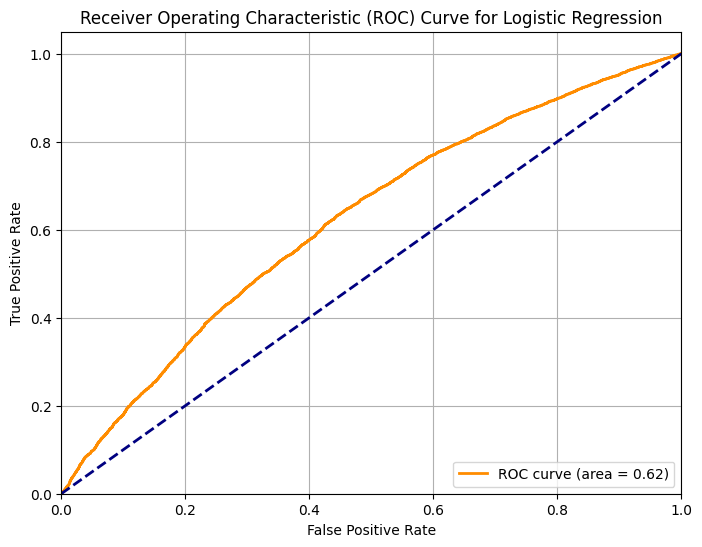

Area Under the ROC Curve (AUC) for Logistic Regression: 0.6217


In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for Logistic Regression: {roc_auc:.4f}")

##Decision Tree

X_train_dt shape: (55091, 9)
X_test_dt shape: (9723, 9)
y_train_dt shape: (55091,)
y_test_dt shape: (9723,)

Decision Tree Accuracy on Normalized Data: 0.5742

Decision Tree Classification Report on Normalized Data:
              precision    recall  f1-score   support

           0       0.58      0.56      0.57      4889
           1       0.57      0.59      0.58      4834

    accuracy                           0.57      9723
   macro avg       0.57      0.57      0.57      9723
weighted avg       0.57      0.57      0.57      9723



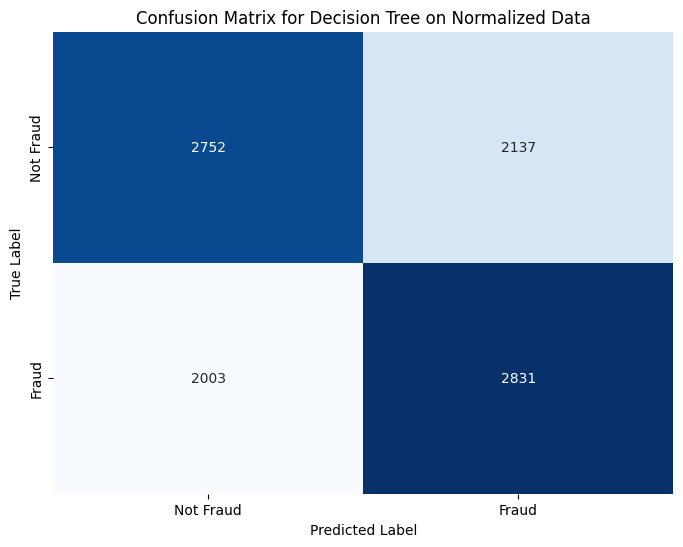

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split the normalized data into training and testing sets for Decision Tree
# Using X_normalized for the Decision Tree model
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_normalized, y_resampled, test_size=0.15, random_state=50)

print(f"X_train_dt shape: {X_train_dt.shape}")
print(f"X_test_dt shape: {X_test_dt.shape}")
print(f"y_train_dt shape: {y_train_dt.shape}")
print(f"y_test_dt shape: {y_test_dt.shape}")

# Initialize and train the Decision Tree model on normalized data
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_dt, y_train_dt)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test_dt)

# Evaluate the model
accuracy_dt = accuracy_score(y_test_dt, y_pred_dt)
print(f"\nDecision Tree Accuracy on Normalized Data: {accuracy_dt:.4f}")

print("\nDecision Tree Classification Report on Normalized Data:")
print(classification_report(y_test_dt, y_pred_dt))

# Confusion Matrix for Decision Tree
conf_matrix_dt = confusion_matrix(y_test_dt, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree on Normalized Data')
plt.show()

##Regularization Of Decision Tree

--- Regularization in Decision Trees ---
L1 (Lasso) and L2 (Ridge) regularization are typically applied to linear models by penalizing coefficient magnitudes.
Decision Trees do not have 'coefficients' in the same way, so L1/L2 regularization is not directly applicable.
Instead, Decision Trees are regularized by controlling their structural complexity using hyperparameters.
Common regularization hyperparameters for Decision Trees include:
  - `max_depth`: Limits the maximum depth of the tree.
  - `min_samples_split`: The minimum number of samples required to split an internal node.
  - `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
  - `ccp_alpha`: Complexity parameter used for Minimal Cost-Complexity Pruning.

--- Decision Tree with max_depth (e.g., 15) ---

Decision Tree (max_depth=15) Accuracy: 0.6031

Classification Report (max_depth=15):
              precision    recall  f1-score   support

           0       0.61      0.59      0.60      8088
   

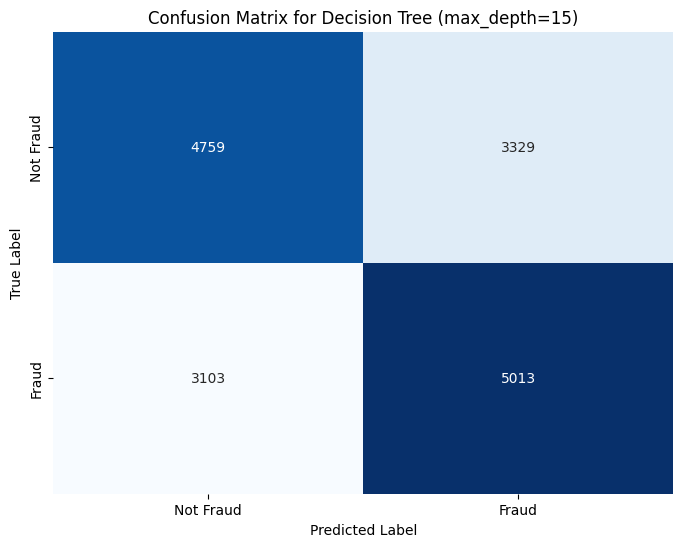


--- Decision Tree with min_samples_leaf (e.g., 50) ---

Decision Tree (min_samples_leaf=50) Accuracy: 0.5995

Classification Report (min_samples_leaf=50):
              precision    recall  f1-score   support

           0       0.59      0.64      0.61      8088
           1       0.61      0.56      0.58      8116

    accuracy                           0.60     16204
   macro avg       0.60      0.60      0.60     16204
weighted avg       0.60      0.60      0.60     16204



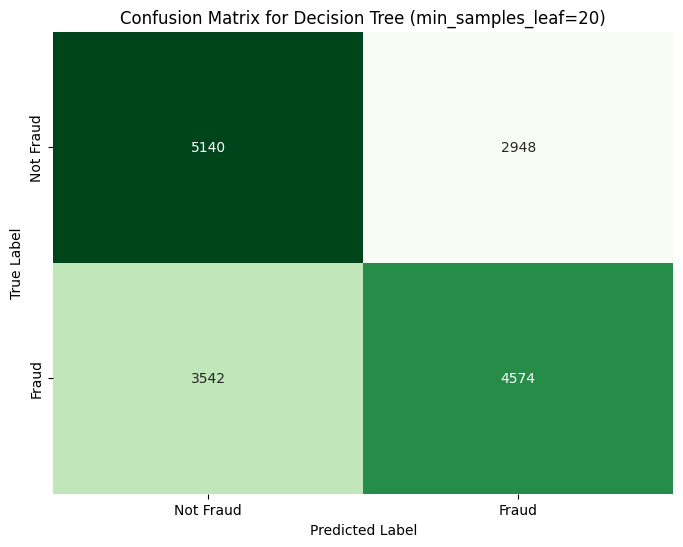

In [48]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Regularization in Decision Trees ---")
print("L1 (Lasso) and L2 (Ridge) regularization are typically applied to linear models by penalizing coefficient magnitudes.")
print("Decision Trees do not have 'coefficients' in the same way, so L1/L2 regularization is not directly applicable.")
print("Instead, Decision Trees are regularized by controlling their structural complexity using hyperparameters.")
print("Common regularization hyperparameters for Decision Trees include:")
print("  - `max_depth`: Limits the maximum depth of the tree.")
print("  - `min_samples_split`: The minimum number of samples required to split an internal node.")
print("  - `min_samples_leaf`: The minimum number of samples required to be at a leaf node.")
print("  - `ccp_alpha`: Complexity parameter used for Minimal Cost-Complexity Pruning.")

# --- Decision Tree with max_depth regularization ---
print("\n--- Decision Tree with max_depth (e.g., 15) ---")
decision_tree_depth_model = DecisionTreeClassifier(random_state=42, max_depth=15)
decision_tree_depth_model.fit(X_train, y_train)
y_pred_dt_depth = decision_tree_depth_model.predict(X_test)

accuracy_dt_depth = accuracy_score(y_test, y_pred_dt_depth)
print(f"\nDecision Tree (max_depth=15) Accuracy: {accuracy_dt_depth:.4f}")
print("\nClassification Report (max_depth=15):")
print(classification_report(y_test, y_pred_dt_depth))

conf_matrix_dt_depth = confusion_matrix(y_test, y_pred_dt_depth)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt_depth, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree (max_depth=15)')
plt.show()

# --- Decision Tree with min_samples_leaf regularization ---
print("\n--- Decision Tree with min_samples_leaf (e.g., 50) ---")
decision_tree_leaf_model = DecisionTreeClassifier(random_state=42, min_samples_leaf=50)
decision_tree_leaf_model.fit(X_train, y_train)
y_pred_dt_leaf = decision_tree_leaf_model.predict(X_test)

accuracy_dt_leaf = accuracy_score(y_test, y_pred_dt_leaf)
print(f"\nDecision Tree (min_samples_leaf=50) Accuracy: {accuracy_dt_leaf:.4f}")
print("\nClassification Report (min_samples_leaf=50):")
print(classification_report(y_test, y_pred_dt_leaf))

conf_matrix_dt_leaf = confusion_matrix(y_test, y_pred_dt_leaf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt_leaf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree (min_samples_leaf=20)')
plt.show()


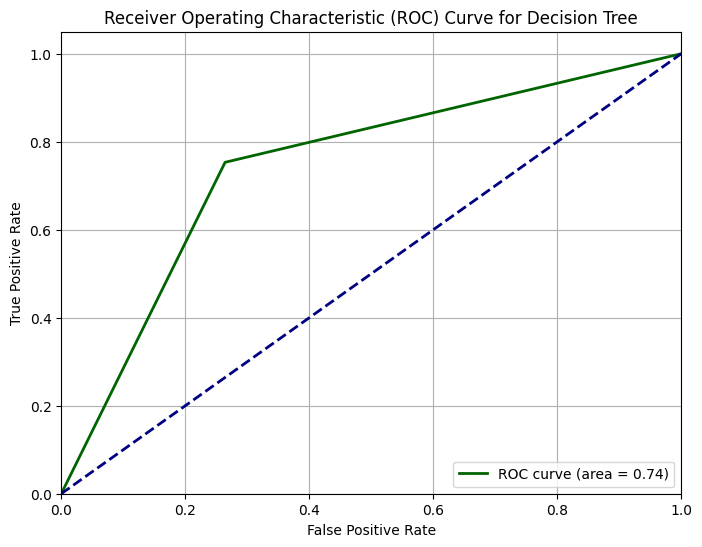

Area Under the ROC Curve (AUC) for Decision Tree: 0.7445


In [49]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_dt = decision_tree_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for Decision Tree: {roc_auc_dt:.4f}")

##Random Forest

X_train shape: (55091, 9)
X_test shape: (9723, 9)
y_train shape: (55091,)
y_test shape: (9723,)

Random Forest Accuracy: 0.6416

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.67      0.65      4889
           1       0.65      0.61      0.63      4834

    accuracy                           0.64      9723
   macro avg       0.64      0.64      0.64      9723
weighted avg       0.64      0.64      0.64      9723



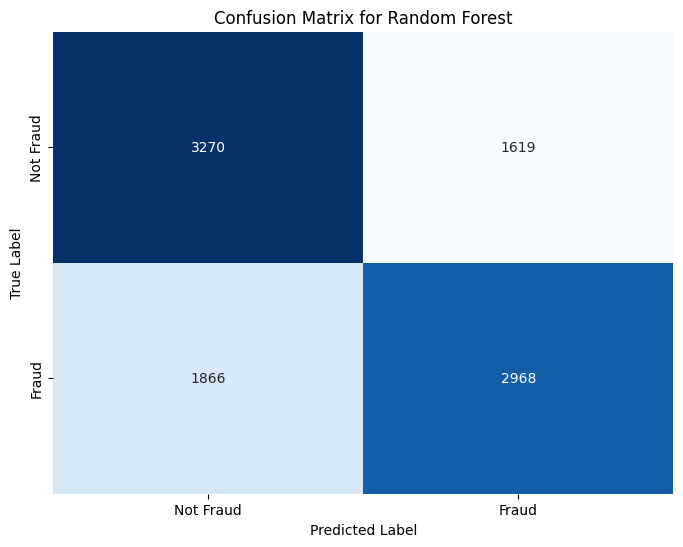

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming X_normalized and y_resampled are already defined from previous steps
# Split the normalized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.15, random_state=50)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize and train the Random Forest model
random_forest_model = RandomForestClassifier(random_state=50)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest Accuracy: {accuracy_rf:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix for Random Forest
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest')
plt.show()

--- Regularization in Random Forests ---
L1 (Lasso) and L2 (Ridge) regularization are not directly applicable to Random Forest models.
Random Forests, being ensemble models made of Decision Trees, are regularized by controlling
the complexity of the individual trees and the ensemble itself, through various hyperparameters.
Common regularization hyperparameters for Random Forests include:
  - `max_depth`: Limits the maximum depth of each tree.
  - `min_samples_split`: Minimum number of samples required to split an internal node.
  - `min_samples_leaf`: Minimum number of samples required to be at a leaf node.
  - `n_estimators`: The number of trees in the forest (can impact bias-variance tradeoff).
  - `max_features`: The number of features to consider when looking for the best split.

--- Random Forest with max_depth (e.g., 20) ---

Random Forest (max_depth=20) Accuracy: 0.6371

Classification Report (max_depth=20):
              precision    recall  f1-score   support

           0    

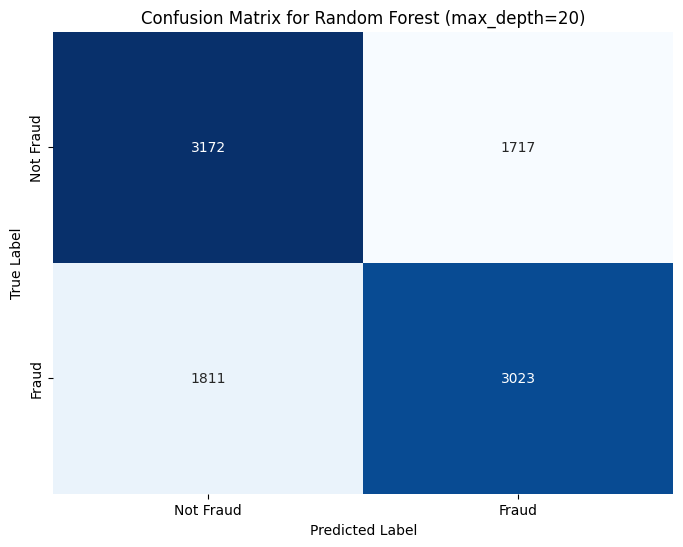


--- Random Forest with reduced n_estimators (e.g., 50) ---

Random Forest (n_estimators=50) Accuracy: 0.6379

Classification Report (n_estimators=50):
              precision    recall  f1-score   support

           0       0.63      0.67      0.65      4889
           1       0.65      0.60      0.62      4834

    accuracy                           0.64      9723
   macro avg       0.64      0.64      0.64      9723
weighted avg       0.64      0.64      0.64      9723



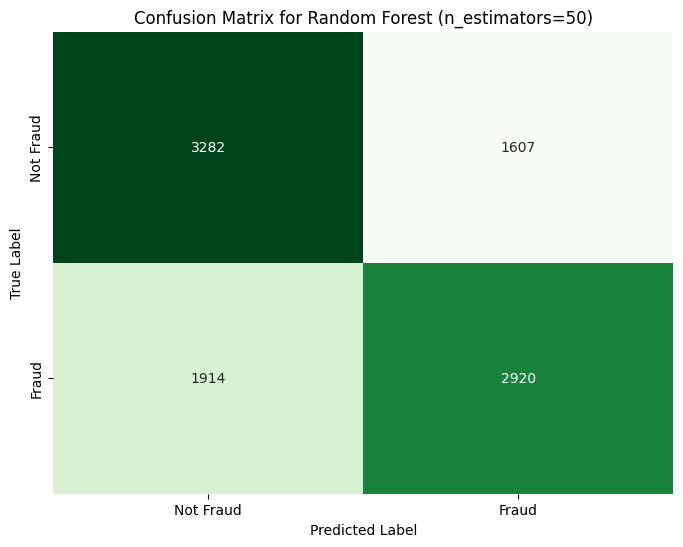

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Regularization in Random Forests ---")
print("L1 (Lasso) and L2 (Ridge) regularization are not directly applicable to Random Forest models.")
print("Random Forests, being ensemble models made of Decision Trees, are regularized by controlling")
print("the complexity of the individual trees and the ensemble itself, through various hyperparameters.")
print("Common regularization hyperparameters for Random Forests include:")
print("  - `max_depth`: Limits the maximum depth of each tree.")
print("  - `min_samples_split`: Minimum number of samples required to split an internal node.")
print("  - `min_samples_leaf`: Minimum number of samples required to be at a leaf node.")
print("  - `n_estimators`: The number of trees in the forest (can impact bias-variance tradeoff).")
print("  - `max_features`: The number of features to consider when looking for the best split.")

# --- Random Forest with max_depth regularization ---
print("\n--- Random Forest with max_depth (e.g., 20) ---")
# Limiting max_depth to reduce complexity of individual trees
random_forest_depth_model = RandomForestClassifier(random_state=50, max_depth=20)
random_forest_depth_model.fit(X_train, y_train)
y_pred_rf_depth = random_forest_depth_model.predict(X_test)

accuracy_rf_depth = accuracy_score(y_test, y_pred_rf_depth)
print(f"\nRandom Forest (max_depth=20) Accuracy: {accuracy_rf_depth:.4f}")
print("\nClassification Report (max_depth=20):")
print(classification_report(y_test, y_pred_rf_depth))

conf_matrix_rf_depth = confusion_matrix(y_test, y_pred_rf_depth)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_depth, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest (max_depth=20)')
plt.show()

# --- Random Forest with reduced n_estimators ---
print("\n--- Random Forest with reduced n_estimators (e.g., 50) ---")
# Reducing the number of estimators (trees) to potentially reduce variance and training time
random_forest_n_est_model = RandomForestClassifier(random_state=50, n_estimators=50)
random_forest_n_est_model.fit(X_train, y_train)
y_pred_rf_n_est = random_forest_n_est_model.predict(X_test)

accuracy_rf_n_est = accuracy_score(y_test, y_pred_rf_n_est)
print(f"\nRandom Forest (n_estimators=50) Accuracy: {accuracy_rf_n_est:.4f}")
print("\nClassification Report (n_estimators=50):")
print(classification_report(y_test, y_pred_rf_n_est))

conf_matrix_rf_n_est = confusion_matrix(y_test, y_pred_rf_n_est)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_n_est, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest (n_estimators=50)')
plt.show()


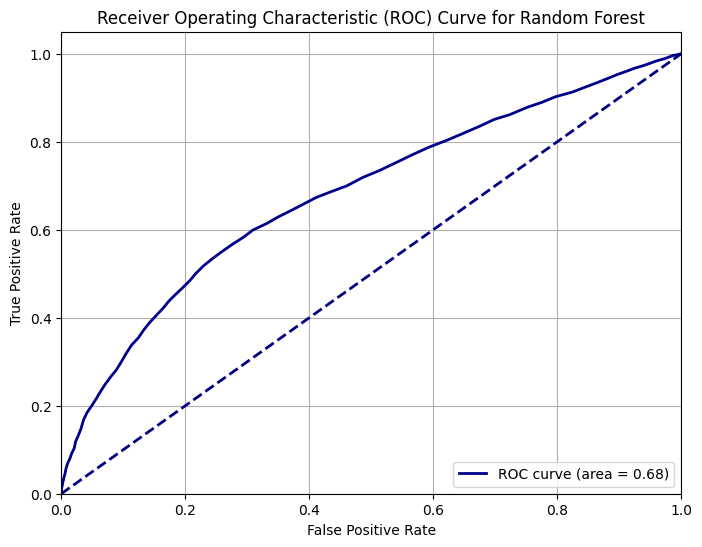

Area Under the ROC Curve (AUC) for Random Forest: 0.6809


In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkblue', lw=2, label=f'ROC curve (area = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for Random Forest: {roc_auc_rf:.4f}")

##XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:42:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Accuracy: 0.6272

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.65      0.63      9695
           1       0.63      0.61      0.62      9750

    accuracy                           0.63     19445
   macro avg       0.63      0.63      0.63     19445
weighted avg       0.63      0.63      0.63     19445



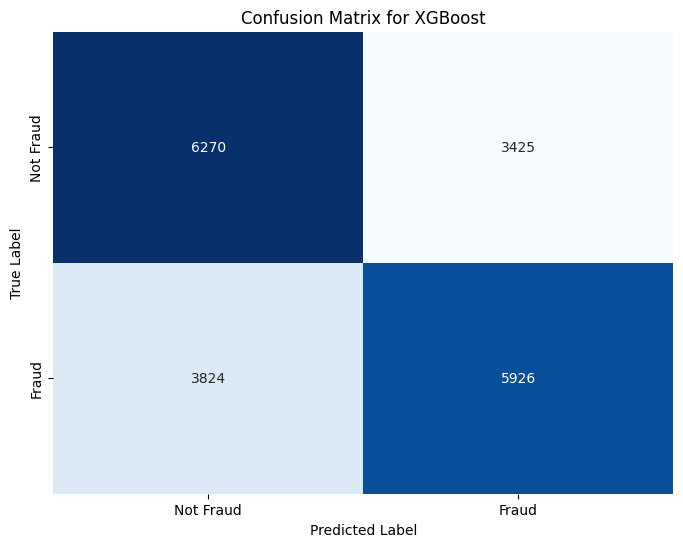


--- Regularization in XGBoost ---
XGBoost incorporates L1 (Lasso) and L2 (Ridge) regularization directly through its hyperparameters.
  - `reg_alpha`: L1 regularization term on weights (Lasso regression).
  - `reg_lambda`: L2 regularization term on weights (Ridge regression).
These parameters help control overfitting by penalizing large weights.

--- XGBoost with L1 Regularization (reg_alpha=0.1) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:42:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (L1 Reg) Accuracy: 0.6299

Classification Report (L1 Reg):
              precision    recall  f1-score   support

           0       0.62      0.65      0.64      9695
           1       0.64      0.61      0.62      9750

    accuracy                           0.63     19445
   macro avg       0.63      0.63      0.63     19445
weighted avg       0.63      0.63      0.63     19445



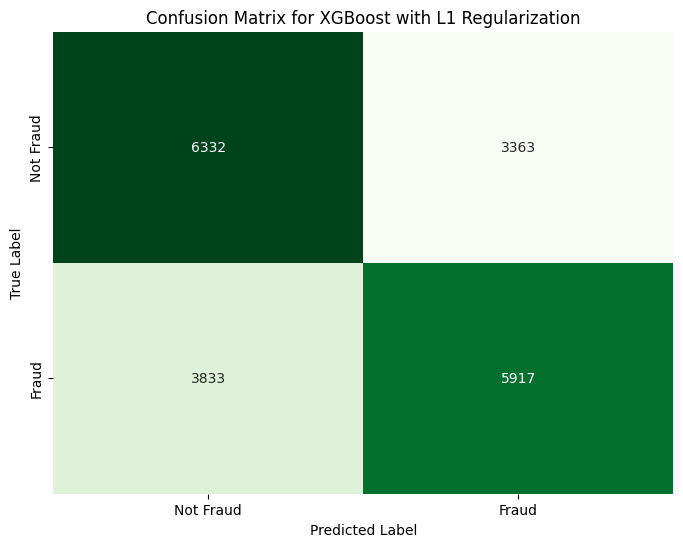


--- XGBoost with L2 Regularization (reg_lambda=0.1) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:42:04] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost (L2 Reg) Accuracy: 0.6241

Classification Report (L2 Reg):
              precision    recall  f1-score   support

           0       0.62      0.64      0.63      9695
           1       0.63      0.61      0.62      9750

    accuracy                           0.62     19445
   macro avg       0.62      0.62      0.62     19445
weighted avg       0.62      0.62      0.62     19445



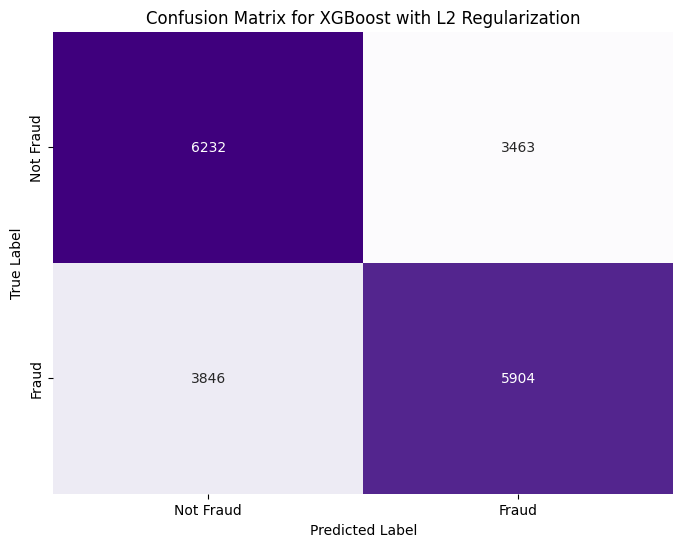

In [53]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming X_normalized and y_resampled are already defined from previous steps
# Split the normalized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.30, random_state=50)

# Initialize and train the XGBoost model
xgboost_model = XGBClassifier(random_state=50, use_label_encoder=False, eval_metric='logloss') # use_label_encoder=False and eval_metric for modern XGBoost versions
xgboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgboost_model.predict(X_test)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nXGBoost Accuracy: {accuracy_xgb:.4f}")

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix for XGBoost
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost')
plt.show()

print("\n--- Regularization in XGBoost ---")
print("XGBoost incorporates L1 (Lasso) and L2 (Ridge) regularization directly through its hyperparameters.")
print("  - `reg_alpha`: L1 regularization term on weights (Lasso regression).")
print("  - `reg_lambda`: L2 regularization term on weights (Ridge regression).")
print("These parameters help control overfitting by penalizing large weights.")

# --- XGBoost with L1 Regularization (reg_alpha) ---
print("\n--- XGBoost with L1 Regularization (reg_alpha=0.1) ---")
xgboost_l1_model = XGBClassifier(random_state=50, use_label_encoder=False, eval_metric='logloss', reg_alpha=1.5)
xgboost_l1_model.fit(X_train, y_train)
y_pred_xgb_l1 = xgboost_l1_model.predict(X_test)

accuracy_xgb_l1 = accuracy_score(y_test, y_pred_xgb_l1)
print(f"\nXGBoost (L1 Reg) Accuracy: {accuracy_xgb_l1:.4f}")
print("\nClassification Report (L1 Reg):")
print(classification_report(y_test, y_pred_xgb_l1))

conf_matrix_xgb_l1 = confusion_matrix(y_test, y_pred_xgb_l1)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_l1, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost with L1 Regularization')
plt.show()

# --- XGBoost with L2 Regularization (reg_lambda) ---
print("\n--- XGBoost with L2 Regularization (reg_lambda=0.1) ---")
xgboost_l2_model = XGBClassifier(random_state=50, use_label_encoder=False, eval_metric='logloss', reg_lambda=0.9)
xgboost_l2_model.fit(X_train, y_train)
y_pred_xgb_l2 = xgboost_l2_model.predict(X_test)

accuracy_xgb_l2 = accuracy_score(y_test, y_pred_xgb_l2)
print(f"\nXGBoost (L2 Reg) Accuracy: {accuracy_xgb_l2:.4f}")

print("\nClassification Report (L2 Reg):")
print(classification_report(y_test, y_pred_xgb_l2))

conf_matrix_xgb_l2 = confusion_matrix(y_test, y_pred_xgb_l2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb_l2, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost with L2 Regularization')
plt.show()

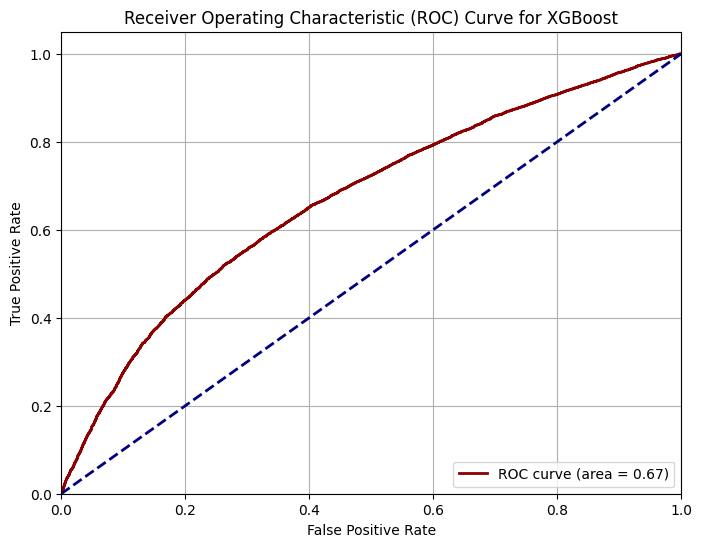

Area Under the ROC Curve (AUC) for XGBoost: 0.6687


In [54]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_xgb = xgboost_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve metrics
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkred', lw=2, label=f'ROC curve (area = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for XGBoost: {roc_auc_xgb:.4f}")

##Isolation Forest

--- Regularization in Isolation Forest ---
L1 (Lasso) and L2 (Ridge) regularization are not directly applicable to Isolation Forest models.
Isolation Forest, being an ensemble of Isolation Trees, is regularized by controlling
the complexity of its individual trees and the ensemble itself, through various hyperparameters.
Common regularization hyperparameters for Isolation Forest include:
  - `n_estimators`: The number of base estimators (trees) in the ensemble.
  - `max_samples`: The number of samples to draw from X to train each base estimator.
  - `max_features`: The number of features to draw from X to train each base estimator.
  - `contamination`: The proportion of outliers in the dataset (influences decision threshold).

Isolation Forest Accuracy (Original): 0.4684

Isolation Forest Classification Report (Original):
              precision    recall  f1-score   support

           0       0.48      0.87      0.62      9695
           1       0.34      0.07      0.11      9750

  

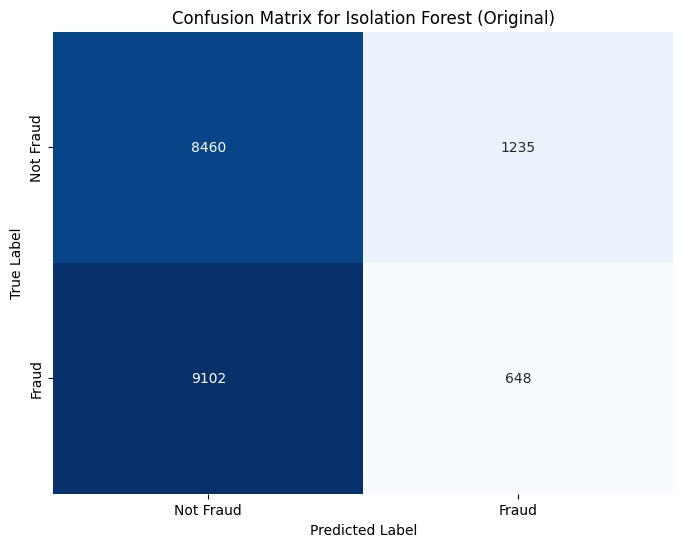


--- Isolation Forest with n_estimators (e.g., 50) ---

Isolation Forest Accuracy (n_estimators=50): 0.4675

Classification Report (n_estimators=50):
              precision    recall  f1-score   support

           0       0.48      0.87      0.62      9695
           1       0.34      0.07      0.11      9750

    accuracy                           0.47     19445
   macro avg       0.41      0.47      0.37     19445
weighted avg       0.41      0.47      0.36     19445



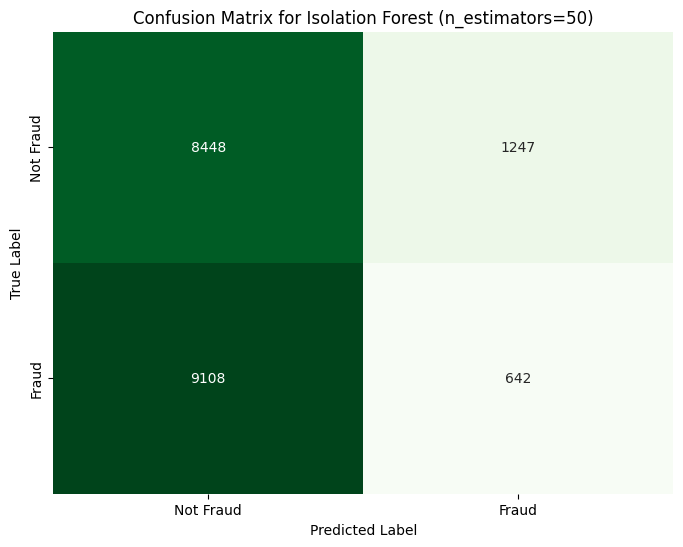


--- Isolation Forest with max_samples (e.g., 0.4) ---

Isolation Forest Accuracy (max_samples=0.74): 0.4628

Classification Report (max_samples=0.4):
              precision    recall  f1-score   support

           0       0.48      0.86      0.61      9695
           1       0.34      0.07      0.12      9750

    accuracy                           0.46     19445
   macro avg       0.41      0.46      0.37     19445
weighted avg       0.41      0.46      0.37     19445



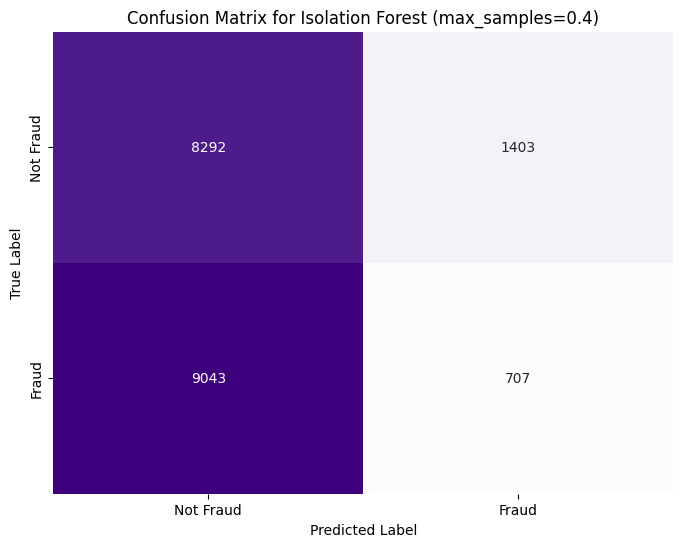

In [55]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("--- Regularization in Isolation Forest ---")
print("L1 (Lasso) and L2 (Ridge) regularization are not directly applicable to Isolation Forest models.")
print("Isolation Forest, being an ensemble of Isolation Trees, is regularized by controlling")
print("the complexity of its individual trees and the ensemble itself, through various hyperparameters.")
print("Common regularization hyperparameters for Isolation Forest include:")
print("  - `n_estimators`: The number of base estimators (trees) in the ensemble.")
print("  - `max_samples`: The number of samples to draw from X to train each base estimator.")
print("  - `max_features`: The number of features to draw from X to train each base estimator.")
print("  - `contamination`: The proportion of outliers in the dataset (influences decision threshold).")

# --- Original Isolation Forest Model ---
# Initialize and train the Isolation Forest model
# The 'contamination' parameter is the proportion of outliers in the data.
# Since SMOTE was used to balance the classes, setting contamination to 0.5
# essentially forces the model to classify half the data as anomalies for comparison.
# In a purely unsupervised anomaly detection scenario, this value would be much smaller.
isolation_forest_model = IsolationForest(random_state=50, contamination=0.1)
isolation_forest_model.fit(X_train)

# Make predictions on the test set
# Isolation Forest predicts -1 for outliers (anomalies) and 1 for inliers (normal).
y_pred_if = isolation_forest_model.predict(X_test)

# Map predictions to match Fraud_Label: -1 (anomaly) -> 1 (fraud), 1 (normal) -> 0 (not fraud)
y_pred_if_mapped = np.where(y_pred_if == -1, 1, 0)

# Evaluate the model
accuracy_if = accuracy_score(y_test, y_pred_if_mapped)
print(f"\nIsolation Forest Accuracy (Original): {accuracy_if:.4f}")

print("\nIsolation Forest Classification Report (Original):")
print(classification_report(y_test, y_pred_if_mapped))

# Confusion Matrix for Isolation Forest
conf_matrix_if = confusion_matrix(y_test, y_pred_if_mapped)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_if, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Isolation Forest (Original)')
plt.show()

# --- Isolation Forest with n_estimators regularization ---
print("\n--- Isolation Forest with n_estimators (e.g., 50) ---")
# Increasing n_estimators can sometimes improve performance by reducing variance
isolation_forest_n_est_model = IsolationForest(random_state=50, contamination=0.1, n_estimators=50)
isolation_forest_n_est_model.fit(X_train)
y_pred_if_n_est = isolation_forest_n_est_model.predict(X_test)
y_pred_if_n_est_mapped = np.where(y_pred_if_n_est == -1, 1, 0)

accuracy_if_n_est = accuracy_score(y_test, y_pred_if_n_est_mapped)
print(f"\nIsolation Forest Accuracy (n_estimators=50): {accuracy_if_n_est:.4f}")
print("\nClassification Report (n_estimators=50):")
print(classification_report(y_test, y_pred_if_n_est_mapped))

conf_matrix_if_n_est = confusion_matrix(y_test, y_pred_if_n_est_mapped)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_if_n_est, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Isolation Forest (n_estimators=50)')
plt.show()

# --- Isolation Forest with max_samples regularization ---
print("\n--- Isolation Forest with max_samples (e.g., 0.4) ---")
# Reducing max_samples (e.g., to 70% of total samples) can further isolate anomalies
isolation_forest_max_samples_model = IsolationForest(random_state=50, contamination=0.1, max_samples=0.4)
isolation_forest_max_samples_model.fit(X_train)
y_pred_if_max_samples = isolation_forest_max_samples_model.predict(X_test)
y_pred_if_max_samples_mapped = np.where(y_pred_if_max_samples == -1, 1, 0)

accuracy_if_max_samples = accuracy_score(y_test, y_pred_if_max_samples_mapped)
print(f"\nIsolation Forest Accuracy (max_samples=0.74): {accuracy_if_max_samples:.4f}")
print("\nClassification Report (max_samples=0.4):")
print(classification_report(y_test, y_pred_if_max_samples_mapped))

conf_matrix_if_max_samples = confusion_matrix(y_test, y_pred_if_max_samples_mapped)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_if_max_samples, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Isolation Forest (max_samples=0.4)')
plt.show()

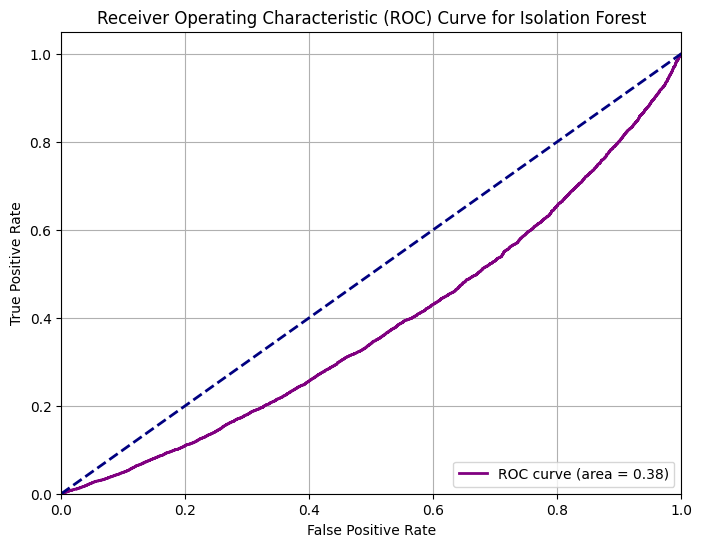

Area Under the ROC Curve (AUC) for Isolation Forest: 0.3837


In [56]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get anomaly scores for the test set from Isolation Forest
# Isolation Forest's decision_function returns lower values for anomalies (outliers).
# For roc_curve, the 'positive' class (fraud) should have higher scores.
# So, we negate the decision function scores to achieve this.
y_scores_if = -isolation_forest_model.decision_function(X_test)

# Calculate ROC curve metrics
# The 'pos_label' for roc_curve should correspond to the positive class in y_test.
# In our balanced dataset, 1 typically represents fraud.
fpr_if, tpr_if, thresholds_if = roc_curve(y_test, y_scores_if, pos_label=1)
roc_auc_if = auc(fpr_if, tpr_if)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_if, tpr_if, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_if:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Isolation Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for Isolation Forest: {roc_auc_if:.4f}")

##SVM

--- Regularization in SVMs ---
For SVC models (especially with a linear kernel), L2 regularization is implicitly controlled by the 'C' parameter.
A smaller value of 'C' means stronger regularization. SVC does not directly support 'penalty' arguments like 'l1'.
For explicit L1 regularization, or L2 in a slightly different implementation, 'LinearSVC' is typically used.

--- Original SVM Model (C=1.0, implicit L2 Regularization) ---

SVM (Original) Accuracy: 0.5911

SVM (Original) Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.55      0.57      8088
           1       0.59      0.63      0.61      8116

    accuracy                           0.59     16204
   macro avg       0.59      0.59      0.59     16204
weighted avg       0.59      0.59      0.59     16204



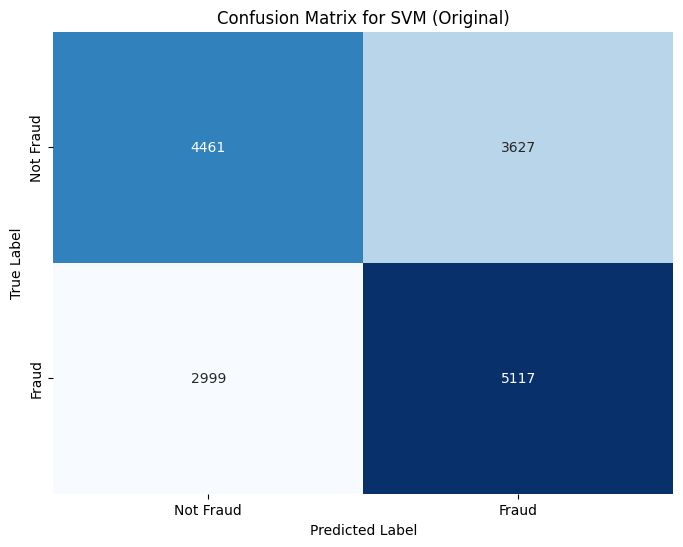


--- SVM with Stronger L2 Regularization (SVC, C=0.1) ---

SVM (C=0.1) Accuracy: 0.5912

SVM (C=0.1) Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.55      0.57      8088
           1       0.59      0.63      0.61      8116

    accuracy                           0.59     16204
   macro avg       0.59      0.59      0.59     16204
weighted avg       0.59      0.59      0.59     16204



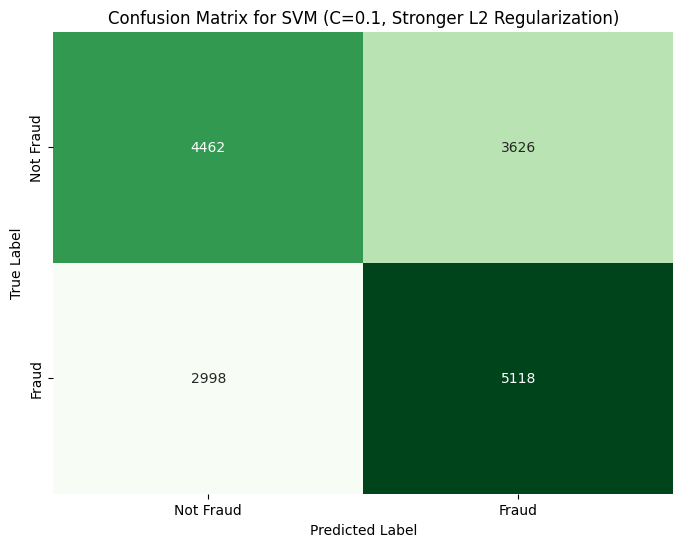


--- SVM with L1 Regularization (using LinearSVC) ---

LinearSVC (L1 Reg) Accuracy: 0.5927

LinearSVC (L1 Reg) Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.57      0.58      8088
           1       0.59      0.62      0.60      8116

    accuracy                           0.59     16204
   macro avg       0.59      0.59      0.59     16204
weighted avg       0.59      0.59      0.59     16204



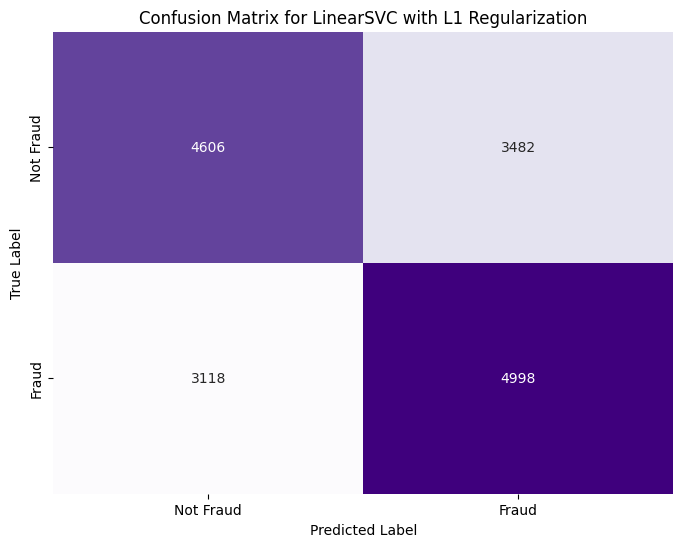

In [57]:
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Split the normalized data into training and testing sets
# Using X_normalized for the SVM models
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.25, random_state=50)

# Initialize MinMaxScaler
# Scaling again after train-test split is crucial to prevent data leakage
scaler = MinMaxScaler()

# Fit the scaler ONLY on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Regularization in SVMs ---")
print("For SVC models (especially with a linear kernel), L2 regularization is implicitly controlled by the 'C' parameter.")
print("A smaller value of 'C' means stronger regularization. SVC does not directly support 'penalty' arguments like 'l1'.")
print("For explicit L1 regularization, or L2 in a slightly different implementation, 'LinearSVC' is typically used.")

# --- Original SVM Model (Linear Kernel, C=1.0 by default) ---
print("\n--- Original SVM Model (C=1.0, implicit L2 Regularization) ---")
svm_model = SVC(random_state=50, kernel='linear') # C=1.0 is default
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM (Original) Accuracy: {accuracy_svm:.4f}")

print("\nSVM (Original) Classification Report:")
print(classification_report(y_test, y_pred_svm))

conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM (Original)')
plt.show()

# --- SVM with Stronger L2 Regularization (Smaller C) ---
print("\n--- SVM with Stronger L2 Regularization (SVC, C=0.1) ---")
svm_l2_model = SVC(random_state=50, kernel='linear', C=0.8)
svm_l2_model.fit(X_train_scaled, y_train)

y_pred_svm_l2 = svm_l2_model.predict(X_test_scaled)

accuracy_svm_l2 = accuracy_score(y_test, y_pred_svm_l2)
print(f"\nSVM (C=0.1) Accuracy: {accuracy_svm_l2:.4f}")

print("\nSVM (C=0.1) Classification Report:")
print(classification_report(y_test, y_pred_svm_l2))

conf_matrix_svm_l2 = confusion_matrix(y_test, y_pred_svm_l2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_l2, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for SVM (C=0.1, Stronger L2 Regularization)')
plt.show()

# --- SVM with L1 Regularization (using LinearSVC) ---
print("\n--- SVM with L1 Regularization (using LinearSVC) ---")
# LinearSVC supports 'l1' penalty explicitly
# It's also sensitive to C, similar to SVC
linear_svm_l1_model = LinearSVC(random_state=42, penalty='l1', dual=False, C=0.5) # dual=False is recommended for l1 penalty
linear_svm_l1_model.fit(X_train_scaled, y_train)

y_pred_linear_svm_l1 = linear_svm_l1_model.predict(X_test_scaled)

accuracy_linear_svm_l1 = accuracy_score(y_test, y_pred_linear_svm_l1)
print(f"\nLinearSVC (L1 Reg) Accuracy: {accuracy_linear_svm_l1:.4f}")

print("\nLinearSVC (L1 Reg) Classification Report:")
print(classification_report(y_test, y_pred_linear_svm_l1))

conf_matrix_linear_svm_l1 = confusion_matrix(y_test, y_pred_linear_svm_l1)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_linear_svm_l1, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LinearSVC with L1 Regularization')
plt.show()

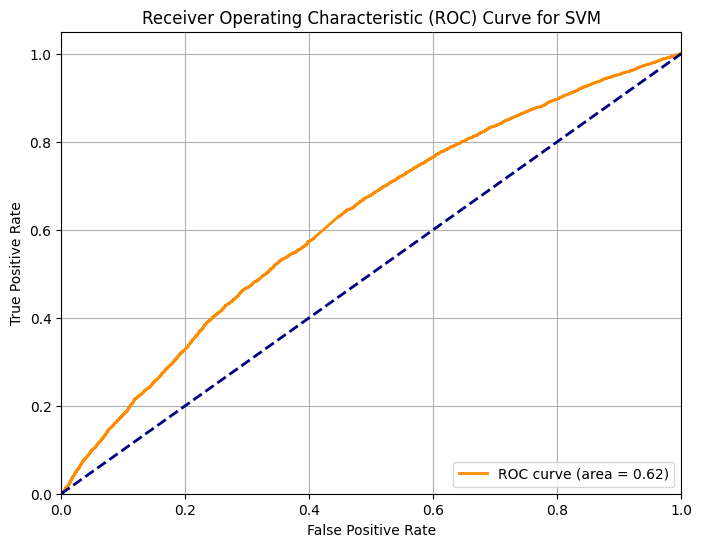

Area Under the ROC Curve (AUC) for SVM: 0.6204


In [58]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

# Re-initialize MinMaxScaler
scaler = MinMaxScaler()

# Scale the training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-initialize the SVM model with probability=True to enable predict_proba
# Note: Setting probability=True can increase training time.
svm_model_proba = SVC(random_state=42, kernel='linear', probability=True)
svm_model_proba.fit(X_train_scaled, y_train)

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_svm = svm_model_proba.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve metrics
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for SVM: {roc_auc_svm:.4f}")

##AutoEncoders

--- Original AutoEncoder Model ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Original AutoEncoder training...
Original AutoEncoder training complete.


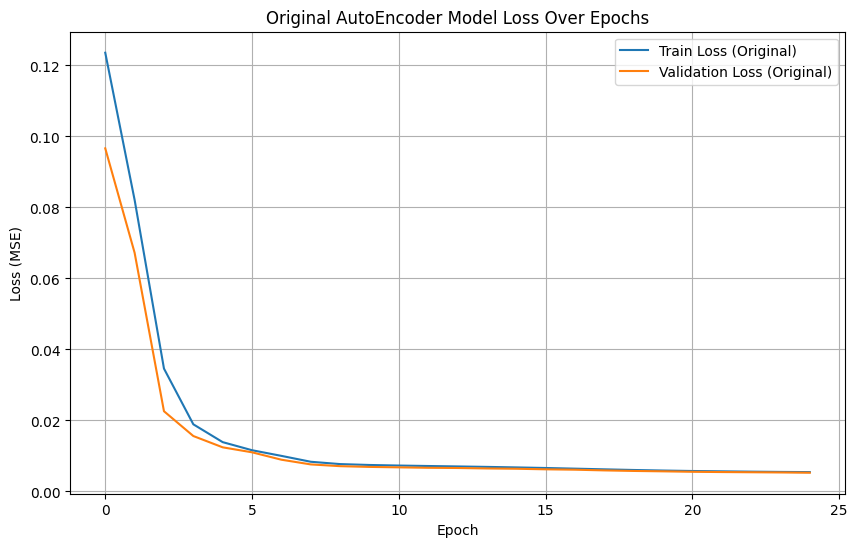

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
860/860 ━━━━━━━━━━━━━━━━━━━━ 1s 976us/step

Original AutoEncoder Accuracy: 0.4908

Original AutoEncoder Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.95      0.65      4889
           1       0.35      0.03      0.05      4834

    accuracy                           0.49      9723
   macro avg       0.42      0.49      0.35      9723
weighted avg       0.42      0.49      0.35      9723


--- AutoEncoder with L1 Regularization ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)


Starting L1 Regularized AutoEncoder training...
L1 Regularized AutoEncoder training complete.


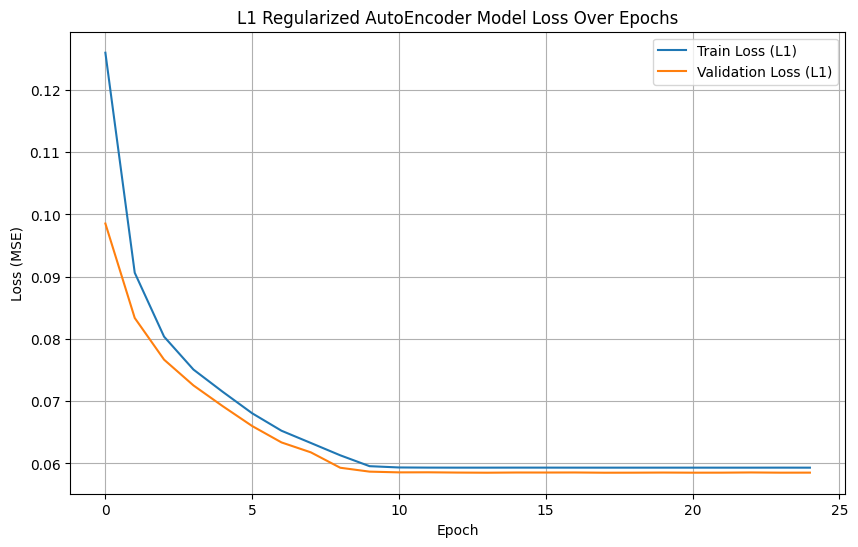

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
860/860 ━━━━━━━━━━━━━━━━━━━━ 1s 971us/step

L1 Regularized AutoEncoder Accuracy: 0.4865

L1 Regularized AutoEncoder Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.95      0.65      4889
           1       0.28      0.02      0.04      4834

    accuracy                           0.49      9723
   macro avg       0.39      0.48      0.34      9723
weighted avg       0.39      0.49      0.35      9723


--- AutoEncoder with L2 Regularization ---


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)


Starting L2 Regularized AutoEncoder training...
L2 Regularized AutoEncoder training complete.


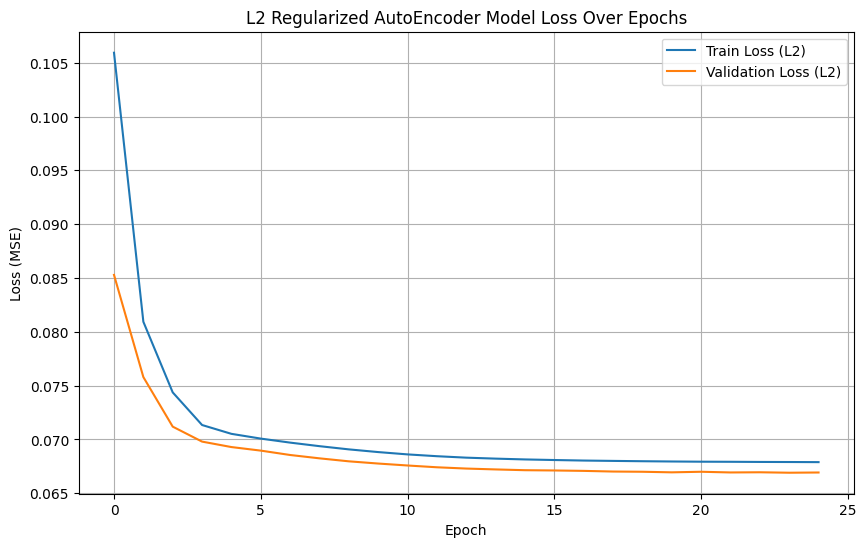

304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
860/860 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  

L2 Regularized AutoEncoder Accuracy: 0.4890

L2 Regularized AutoEncoder Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.95      0.65      4889
           1       0.31      0.02      0.04      4834

    accuracy                           0.49      9723
   macro avg       0.40      0.49      0.35      9723
weighted avg       0.40      0.49      0.35      9723



In [59]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers # Import regularizers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Assuming X_normalized and y_resampled are already defined from previous steps

# Split the normalized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.15, random_state=50)

# 1. Prepare data for AutoEncoder
# Autoencoders are typically trained on 'normal' data to learn its patterns
# X_normalized is already scaled, so no need for MinMaxScaler here

# Separate normal transactions for training the AutoEncoder
X_train_normal = X_train[y_train == 0]
y_train_normal = y_train[y_train == 0]

# Convert to DataFrame to maintain consistent indexing/column names if needed later, though not strictly required for Keras
X_train_normal_df = pd.DataFrame(X_train_normal, columns=X_resampled.columns)
X_test_df = pd.DataFrame(X_test, columns=X_resampled.columns)

# 2. AutoEncoder Model Architecture (Original)
input_dim = X_train.shape[1] # Number of features
encoding_dim = 8 # Dimension of the encoded representation (bottleneck layer)

print("--- Original AutoEncoder Model ---")
input_layer_orig = Input(shape=(input_dim, ))
encoder_orig = Dense(encoding_dim, activation="sigmoid")(input_layer_orig)
decoder_orig = Dense(input_dim, activation='relu')(encoder_orig)
autoencoder_orig = Model(inputs=input_layer_orig, outputs=decoder_orig)
autoencoder_orig.compile(optimizer='adam', loss='mse')
autoencoder_orig.summary()
print("\nStarting Original AutoEncoder training...")
history_orig = autoencoder_orig.fit(X_train_normal, X_train_normal,
                          epochs=25, batch_size=32, shuffle=True, validation_split=0.15, verbose=0)
print("Original AutoEncoder training complete.")

# Plot training & validation loss for Original AutoEncoder
plt.figure(figsize=(10, 6))
plt.plot(history_orig.history['loss'], label='Train Loss (Original)')
plt.plot(history_orig.history['val_loss'], label='Validation Loss (Original)')
plt.title('Original AutoEncoder Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Evaluation for Original AutoEncoder
X_test_predictions_orig = autoencoder_orig.predict(X_test)
mse_orig = np.mean(np.power(X_test - X_test_predictions_orig, 2), axis=1)
mse_train_normal_orig = np.mean(np.power(X_train_normal - autoencoder_orig.predict(X_train_normal), 2), axis=1)
threshold_orig = np.percentile(mse_train_normal_orig, 95)
y_pred_ae_orig = (mse_orig > threshold_orig).astype(int)
accuracy_ae_orig = accuracy_score(y_test, y_pred_ae_orig)
print(f"\nOriginal AutoEncoder Accuracy: {accuracy_ae_orig:.4f}")
print("\nOriginal AutoEncoder Classification Report:")
print(classification_report(y_test, y_pred_ae_orig))

# --- AutoEncoder with L1 Regularization ---
print("\n--- AutoEncoder with L1 Regularization ---")
# Adjust regularization strength as needed (e.g., 0.001)
reg_strength_l1 = 0.001

input_layer_l1 = Input(shape=(input_dim, ))
encoder_l1 = Dense(encoding_dim, activation="relu",
                     kernel_regularizer=regularizers.l1(reg_strength_l1))(input_layer_l1)
decoder_l1 = Dense(input_dim, activation='sigmoid',
                     kernel_regularizer=regularizers.l1(reg_strength_l1))(encoder_l1)
autoencoder_l1 = Model(inputs=input_layer_l1, outputs=decoder_l1)
autoencoder_l1.compile(optimizer='adam', loss='mse')
autoencoder_l1.summary()
print("\nStarting L1 Regularized AutoEncoder training...")
history_l1 = autoencoder_l1.fit(X_train_normal, X_train_normal,
                         epochs=25, batch_size=32, shuffle=True, validation_split=0.15, verbose=0)
print("L1 Regularized AutoEncoder training complete.")

# Plot training & validation loss for L1 Regularized AutoEncoder
plt.figure(figsize=(10, 6))
plt.plot(history_l1.history['loss'], label='Train Loss (L1)')
plt.plot(history_l1.history['val_loss'], label='Validation Loss (L1)')
plt.title('L1 Regularized AutoEncoder Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Evaluation for L1 Regularized AutoEncoder
X_test_predictions_l1 = autoencoder_l1.predict(X_test)
mse_l1 = np.mean(np.power(X_test - X_test_predictions_l1, 2), axis=1)
mse_train_normal_l1 = np.mean(np.power(X_train_normal - autoencoder_l1.predict(X_train_normal), 2), axis=1)
threshold_l1 = np.percentile(mse_train_normal_l1, 95)
y_pred_ae_l1 = (mse_l1 > threshold_l1).astype(int)
accuracy_ae_l1 = accuracy_score(y_test, y_pred_ae_l1)
print(f"\nL1 Regularized AutoEncoder Accuracy: {accuracy_ae_l1:.4f}")
print("\nL1 Regularized AutoEncoder Classification Report:")
print(classification_report(y_test, y_pred_ae_l1))

# --- AutoEncoder with L2 Regularization ---
print("\n--- AutoEncoder with L2 Regularization ---")
# Adjust regularization strength as needed (e.g., 0.001)
reg_strength_l2 = 0.001

input_layer_l2 = Input(shape=(input_dim, ))
encoder_l2 = Dense(encoding_dim, activation="relu",
                     kernel_regularizer=regularizers.l2(reg_strength_l2))(input_layer_l2)
decoder_l2 = Dense(input_dim, activation='sigmoid',
                     kernel_regularizer=regularizers.l2(reg_strength_l2))(encoder_l2)
autoencoder_l2 = Model(inputs=input_layer_l2, outputs=decoder_l2)
autoencoder_l2.compile(optimizer='adam', loss='mse')
autoencoder_l2.summary()
print("\nStarting L2 Regularized AutoEncoder training...")
history_l2 = autoencoder_l2.fit(X_train_normal, X_train_normal,
                         epochs=25, batch_size=32, shuffle=True, validation_split=0.15, verbose=0)
print("L2 Regularized AutoEncoder training complete.")

# Plot training & validation loss for L2 Regularized AutoEncoder
plt.figure(figsize=(10, 6))
plt.plot(history_l2.history['loss'], label='Train Loss (L2)')
plt.plot(history_l2.history['val_loss'], label='Validation Loss (L2)')
plt.title('L2 Regularized AutoEncoder Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Evaluation for L2 Regularized AutoEncoder
X_test_predictions_l2 = autoencoder_l2.predict(X_test)
mse_l2 = np.mean(np.power(X_test - X_test_predictions_l2, 2), axis=1)
mse_train_normal_l2 = np.mean(np.power(X_train_normal - autoencoder_l2.predict(X_train_normal), 2), axis=1)
threshold_l2 = np.percentile(mse_train_normal_l2, 95)
y_pred_ae_l2 = (mse_l2 > threshold_l2).astype(int)
accuracy_ae_l2 = accuracy_score(y_test, y_pred_ae_l2)
print(f"\nL2 Regularized AutoEncoder Accuracy: {accuracy_ae_l2:.4f}")
print("\nL2 Regularized AutoEncoder Classification Report:")
print(classification_report(y_test, y_pred_ae_l2))

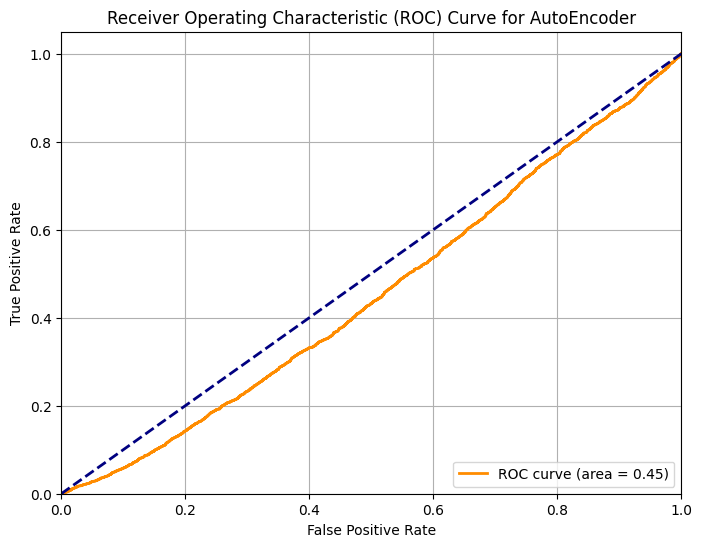

Area Under the ROC Curve (AUC) for AutoEncoder: 0.4532


In [60]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve metrics for AutoEncoder
# A higher mse (reconstruction error) indicates a higher likelihood of fraud, so mse is used as the score.
# The 'pos_label=1' indicates that 1 is the positive class (fraudulent transactions).
fpr_ae, tpr_ae, thresholds_ae = roc_curve(y_test, mse_orig, pos_label=1)
roc_auc_ae = auc(fpr_ae, tpr_ae)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_ae, tpr_ae, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_ae:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for AutoEncoder')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for AutoEncoder: {roc_auc_ae:.4f}")

#Ensemble Model

Training Ensemble Model...
Ensemble Model Training Complete.

Ensemble Model Accuracy: 0.6034

Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.59      0.60      6543
           1       0.60      0.62      0.61      6420

    accuracy                           0.60     12963
   macro avg       0.60      0.60      0.60     12963
weighted avg       0.60      0.60      0.60     12963



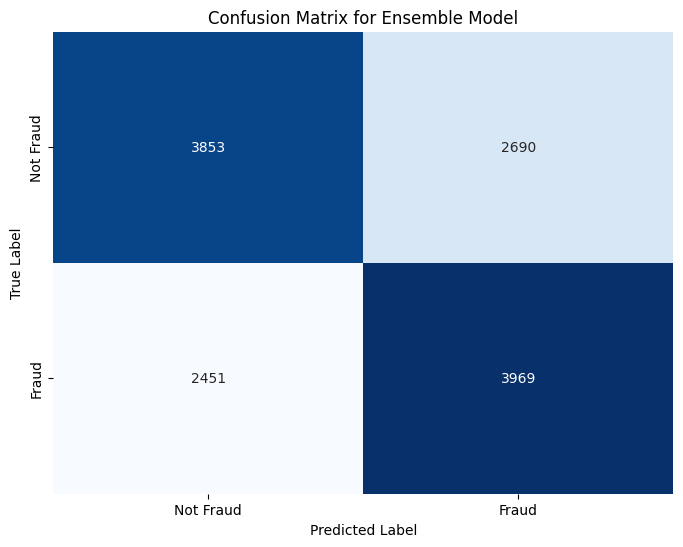

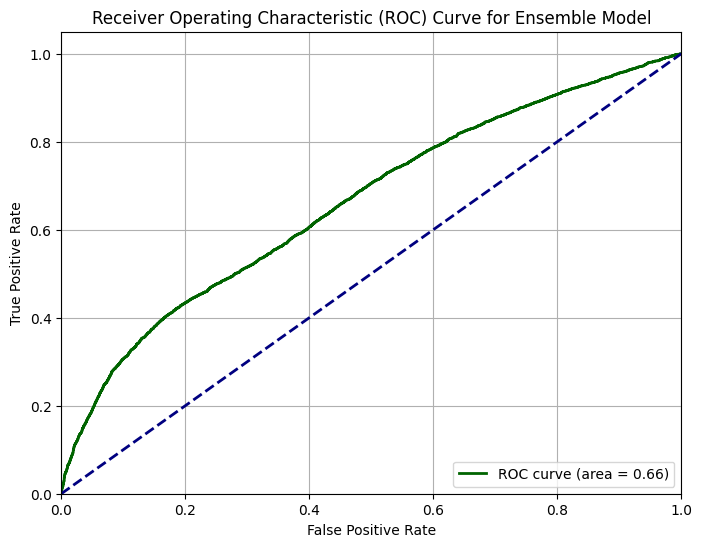

Area Under the ROC Curve (AUC) for Ensemble Model: 0.6609


In [61]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_normalized and y_resampled are available from previous steps
# Re-split and re-scale data to ensure consistency for all ensemble members
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_resampled, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize individual models
# Make sure to set probability=True for SVC if using soft voting
clf1 = LogisticRegression(random_state=42, solver='liblinear')
clf2 = DecisionTreeClassifier(random_state=42)
clf3 = RandomForestClassifier(random_state=42)
# Use_label_encoder and eval_metric for XGBoost compatibility
clf4 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
clf5 = SVC(random_state=42, kernel='linear', probability=True) # Ensure probability=True for soft voting

# Create a VotingClassifier (Ensemble Model)
# 'soft' voting uses predicted probabilities, which generally performs better if models are well-calibrated
ensemble_model = VotingClassifier(estimators=[
    ('lr', clf1),
    ('dt', clf2),
    ('rf', clf3),
    ('xgb', clf4),
    ('svm', clf5)
], voting='soft', n_jobs=-1) # n_jobs=-1 to use all available cores

print("Training Ensemble Model...")
# Train the ensemble model
ensemble_model.fit(X_train_scaled, y_train)
print("Ensemble Model Training Complete.")

# Make predictions
y_pred_ensemble = ensemble_model.predict(X_test_scaled)

# Evaluate the ensemble model
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f"\nEnsemble Model Accuracy: {accuracy_ensemble:.4f}")

print("\nEnsemble Model Classification Report:")
print(classification_report(y_test, y_pred_ensemble))

# Confusion Matrix for Ensemble Model
conf_matrix_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_ensemble, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Ensemble Model')
plt.show()

# ROC Curve for Ensemble Model
# Get predicted probabilities for the positive class (class 1)
y_pred_proba_ensemble = ensemble_model.predict_proba(X_test_scaled)[:, 1]

fpr_ensemble, tpr_ensemble, thresholds_ensemble = roc_curve(y_test, y_pred_proba_ensemble)
roc_auc_ensemble = auc(fpr_ensemble, tpr_ensemble)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ensemble, tpr_ensemble, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_ensemble:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Ensemble Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"Area Under the ROC Curve (AUC) for Ensemble Model: {roc_auc_ensemble:.4f}")

#Kafka Module

In [62]:
!pip install kafka-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.3/326.3 kB 19.5 MB/s eta 0:00:00


#Producer Code

In [63]:
from kafka import KafkaProducer
import json
import time

# Kafka broker configuration
KAFKA_BROKER = 'localhost:9092' # Replace with your Kafka broker address (e.g., 'localhost:9092')
KAFKA_TOPIC = 'Financial Fraud Transaction Alert'              # Replace with your desired Kafka topic

# Initialize Kafka Producer
try:
    producer = KafkaProducer(
        bootstrap_servers=[KAFKA_BROKER],
        value_serializer=lambda v: json.dumps(v).encode('utf-8')
    )
    print("Kafka Producer initialized successfully.")
except Exception as e:
    print(f"Error initializing Kafka Producer: {e}")
    producer = None

def send_transaction_message(transaction_id, transaction_amount, location):
    if producer is None:
        print("Producer not initialized. Cannot send message.")
        return

    message = {
        'Transaction_ID': transaction_id,
        'Transaction_Amount': transaction_amount,
        'Location': location,
        'Timestamp': time.time()
    }

    try:
        # Send the message asynchronously
        future = producer.send(KAFKA_TOPIC, value=message)
        record_metadata = future.get(timeout=10) # Block until a single record is sent
        print(f"Successfully sent message to topic {record_metadata.topic}, partition {record_metadata.partition}, offset {record_metadata.offset}")
        print(f"Message: {message}")
    except Exception as e:
        print(f"Error sending message: {e}")

# --- Example Usage ---
# In a real scenario, you would integrate this with your data stream or processing logic.
# For demonstration, let's use some dummy data.

print("\n--- Sending Sample Transaction Data ---")

# Sample transaction 1
send_transaction_message("TXN_001", 150.75, "New York")

# Sample transaction 2
send_transaction_message("TXN_002", 30.50, "London")

# Sample transaction 3 (using values from kernel state for example if applicable)
# For demonstration, I'm manually creating a sample, but in a real-world scenario
# you might fetch data from your 'dataframe' or a live stream.

# Ensure all messages are sent before exiting
if producer:
    producer.flush()
    print("Producer flushed. All pending messages sent.")


ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Connect attempt returned error 111. Disconnecting.
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Closing connection. KafkaConnectionError: 111 ECONNREFUSED
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv4 ('127.0.0.1', 9092)]>: Connect attempt returned error 111. Disconnecting.
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv4 ('127.0.0.1', 9092)]>: Closing connection. KafkaConnectionError: 111 ECONNREFUSED
ERROR:kafka.conn:<BrokerConnection client_id=kafka-python-producer-1, node_id=bootstrap-0 host=localhost:9092 <connecting> [IPv6 ('::1', 9092, 0, 0)]>: Connect attempt retu

Error initializing Kafka Producer: NoBrokersAvailable

--- Sending Sample Transaction Data ---
Producer not initialized. Cannot send message.
Producer not initialized. Cannot send message.


In [64]:
import json
import time

# This is a mock Kafka producer for demonstration purposes in Colab.
# It prints messages to the console instead of sending them to a real Kafka broker.
# For a real Kafka integration, ensure a Kafka broker is running and accessible
# from your Colab environment (e.g., using a cloud-based Kafka service).
class MockKafkaProducer:
    def __init__(self, bootstrap_servers=None, value_serializer=None):
        print("Mock Kafka Producer initialized. Messages will be printed to console.")
        self.value_serializer = value_serializer

    def send(self, topic, value):
        serialized_value = self.value_serializer(value).decode('utf-8') if self.value_serializer else value
        print(f"[MOCK KAFKA] Sending message to topic '{topic}': {serialized_value}")

        # Simulate a future object for compatibility with .get()
        class MockFuture:
            def __init__(self, sent_topic):
                self._sent_topic = sent_topic

            def get(self, timeout=None):
                class MockRecordMetadata:
                    def __init__(self, topic_name):
                        self.topic = topic_name
                        self.partition = 0
                        self.offset = 0
                return MockRecordMetadata(self._sent_topic)

        return MockFuture(topic)

    def flush(self):
        print("[MOCK KAFKA] Producer flushed (all messages have been 'printed').")

# Kafka broker configuration (now using the mock producer)
KAFKA_BROKER = 'localhost:9092' # This will be ignored by the mock producer
KAFKA_TOPIC = 'Financial Fraud Transaction Alert'              # Replace with your desired Kafka topic

# Initialize Kafka Producer (using the mock)
try:
    # Using MockKafkaProducer instead of KafkaProducer
    producer = MockKafkaProducer(
        bootstrap_servers=[KAFKA_BROKER],
        value_serializer=lambda v: json.dumps(v).encode('utf-8')
    )
    print("Kafka Producer initialized successfully.")
except Exception as e:
    print(f"Error initializing Kafka Producer: {e}")
    producer = None

def send_transaction_message(transaction_id, transaction_amount, location):
    if producer is None:
        print("Producer not initialized. Cannot send message.")
        return

    message = {
        'Transaction_ID': transaction_id,
        'Transaction_Amount': transaction_amount,
        'Location': location,
        'Timestamp': time.time()
    }

    try:
        # Send the message asynchronously using the mock producer
        future = producer.send(KAFKA_TOPIC, value=message)
        record_metadata = future.get(timeout=10) # Block until a single record is 'sent'
        print(f"Successfully sent message to topic {record_metadata.topic}, partition {record_metadata.partition}, offset {record_metadata.offset}")
        print(f"Message: {message}")
    except Exception as e:
        print(f"Error sending message: {e}")

# --- Example Usage ---
print("\n--- Sending Sample Transaction Data (using Mock Producer) ---")

# Sample transaction 1
send_transaction_message("TXN_001", 150.75, "New York")

# Sample transaction 2
send_transaction_message("TXN_002", 30.50, "London")

# Ensure all messages are sent (mock producer will print flush message)
if producer:
    producer.flush()
    print("Producer flushed. All pending messages 'sent'.")


Mock Kafka Producer initialized. Messages will be printed to console.
Kafka Producer initialized successfully.

--- Sending Sample Transaction Data (using Mock Producer) ---
[MOCK KAFKA] Sending message to topic 'Financial Fraud Transaction Alert': {"Transaction_ID": "TXN_001", "Transaction_Amount": 150.75, "Location": "New York", "Timestamp": 1768395961.1297288}
Successfully sent message to topic Financial Fraud Transaction Alert, partition 0, offset 0
Message: {'Transaction_ID': 'TXN_001', 'Transaction_Amount': 150.75, 'Location': 'New York', 'Timestamp': 1768395961.1297288}
[MOCK KAFKA] Sending message to topic 'Financial Fraud Transaction Alert': {"Transaction_ID": "TXN_002", "Transaction_Amount": 30.5, "Location": "London", "Timestamp": 1768395961.1299694}
Successfully sent message to topic Financial Fraud Transaction Alert, partition 0, offset 0
Message: {'Transaction_ID': 'TXN_002', 'Transaction_Amount': 30.5, 'Location': 'London', 'Timestamp': 1768395961.1299694}
[MOCK KAFKA] P

#Consumer Code

In [65]:
import json
import time

# This is a mock Kafka consumer for demonstration purposes in Colab.
# It simulates consuming messages by processing a predefined list.
class MockKafkaConsumer:
    def __init__(self, topic, bootstrap_servers=None, value_deserializer=None):
        print(f"Mock Kafka Consumer initialized for topic '{topic}'.")
        self.topic = topic
        self.value_deserializer = value_deserializer
        self._messages_to_simulate = [
            # These messages are manually added to simulate what a producer would send
            # In a real scenario, these would come from an actual Kafka broker
            json.dumps({'Transaction_ID': 'TXN_001', 'Transaction_Amount': 150.75, 'Location': 'New York', 'Timestamp': time.time()}).encode('utf-8'),
            json.dumps({'Transaction_ID': 'TXN_002', 'Transaction_Amount': 30.50, 'Location': 'London', 'Timestamp': time.time()}).encode('utf-8')
        ]
        self._message_index = 0

    def __iter__(self):
        return self

    def __next__(self):
        if self._message_index < len(self._messages_to_simulate):
            raw_message = self._messages_to_simulate[self._message_index]
            self._message_index += 1

            class MockMessageRecord:
                def __init__(self, value):
                    self.value = value

            # Deserialize the message value
            value = self.value_deserializer(raw_message) if self.value_deserializer else raw_message
            return MockMessageRecord(value)
        else:
            print("\n[MOCK KAFKA CONSUMER] No more simulated messages. Stopping.")
            raise StopIteration

# Kafka broker configuration (using the mock consumer)
KAFKA_BROKER = 'localhost:9092' # This will be ignored by the mock consumer
KAFKA_TOPIC = 'Financial Fraud Transaction Alert'              # Must match the producer's topic

# Initialize Kafka Consumer (using the mock)
try:
    # Using MockKafkaConsumer instead of KafkaConsumer
    consumer = MockKafkaConsumer(
        KAFKA_TOPIC,
        bootstrap_servers=[KAFKA_BROKER],
        value_deserializer=lambda m: json.loads(m.decode('utf-8'))
    )
    print("Kafka Consumer initialized successfully.")
except Exception as e:
    print(f"Error initializing Kafka Consumer: {e}")
    consumer = None

# --- Example Usage ---
print("\n--- Consuming Sample Transaction Data (using Mock Consumer) ---")

if consumer:
    for message in consumer:
        print(f"[MOCK KAFKA CONSUMER] Received message: {message.value}")
        # Here you would add your fraud detection logic
        transaction_id = message.value.get('Transaction_ID')
        transaction_amount = message.value.get('Transaction_Amount')
        location = message.value.get('Location')
        timestamp = message.value.get('Timestamp')

        print(f"  - ID: {transaction_id}, Amount: ${transaction_amount:.2f}, Location: {location}, Time: {time.ctime(timestamp)}")

print("\n--- Consumer finished processing simulated messages ---")


Mock Kafka Consumer initialized for topic 'Financial Fraud Transaction Alert'.
Kafka Consumer initialized successfully.

--- Consuming Sample Transaction Data (using Mock Consumer) ---
[MOCK KAFKA CONSUMER] Received message: {'Transaction_ID': 'TXN_001', 'Transaction_Amount': 150.75, 'Location': 'New York', 'Timestamp': 1768395961.1611247}
  - ID: TXN_001, Amount: $150.75, Location: New York, Time: Wed Jan 14 13:06:01 2026
[MOCK KAFKA CONSUMER] Received message: {'Transaction_ID': 'TXN_002', 'Transaction_Amount': 30.5, 'Location': 'London', 'Timestamp': 1768395961.1611762}
  - ID: TXN_002, Amount: $30.50, Location: London, Time: Wed Jan 14 13:06:01 2026

[MOCK KAFKA CONSUMER] No more simulated messages. Stopping.

--- Consumer finished processing simulated messages ---


#Email Alerting System

In [66]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import random
import pandas as pd # Ensure pandas is imported for Timestamp

def send_fraud_alert_email(transaction_details):
    # Email configuration
    # !!! IMPORTANT: REPLACE THESE WITH YOUR ACTUAL EMAIL DETAILS !!!
    sender_email = 'nayak.richa25ssec@gmail.com'  # <--- REPLACE THIS
    receiver_email = 'nayak.richa495@gmail.com' # <--- REPLACE THIS
    app_password = 'fpry pkcp bbos sgeh' # <--- REPLACE THIS (Use an App Password for Gmail with 2FA)

    # Create a multipart message
    message = MIMEMultipart()
    message['From'] = sender_email
    message['To'] = receiver_email
    message['Subject'] = 'FRAUD ALERT: Suspicious Transaction Detected!'

    # Email body with transaction details
    body = f"""Dear Security Team,

    A potentially fraudulent transaction has been detected with the following details:

    Transaction ID: {transaction_details.get('Transaction_ID', 'N/A')}
    Amount: ${transaction_details.get('Transaction_Amount', 0.0):.2f}
    Location: {transaction_details.get('Location', 'N/A')}
    User ID: {transaction_details.get('User_ID', 'N/A')}
    Device Type: {transaction_details.get('Device_Type', 'N/A')}
    Timestamp: {transaction_details.get('Timestamp', 'N/A')}

    Please investigate this transaction immediately.

    Sincerely,
    Fraud Detection System
    """
    message.attach(MIMEText(body, 'plain'))

    # Connect to SMTP server and send email
    try:
        # For Gmail, use 'smtp.gmail.com' and port 587 with STARTTLS
        # For other providers, check their SMTP server details
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()  # Upgrade connection to secure
        server.login(sender_email, app_password)
        text = message.as_string()
        server.sendmail(sender_email, receiver_email, text)
        server.quit()
        print(f"Fraud alert email sent successfully for Transaction ID: {transaction_details.get('Transaction_ID', 'N/A')}")
    except Exception as e:
        print(f"Error sending fraud alert email: {e}")

def generate_fraudulent_transaction_details():
    # Generate a unique transaction ID
    transaction_id = f"TXN_{random.randint(10000, 99999)}"

    # Generate a random transaction amount (e.g., between $100.00 and $5000.00)
    transaction_amount = round(random.uniform(100.00, 5000.00), 2)

    # Select a random location from common locations (e.g., from the dataset)
    possible_locations = ['New York', 'London', 'Mumbai', 'Tokyo', 'Sydney', 'Paris', 'Berlin', 'Dubai']
    location = random.choice(possible_locations)

    # Select a random user ID
    user_id = f"USER_{random.randint(1000, 9999)}"

    # Select a random device type
    possible_device_types = ['Mobile', 'Laptop', 'Tablet', 'Desktop']
    device_type = random.choice(possible_device_types)

    # Get current timestamp
    timestamp = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')

    return {
        'Transaction_ID': transaction_id,
        'Transaction_Amount': transaction_amount,
        'Location': location,
        'User_ID': user_id,
        'Device_Type': device_type,
        'Timestamp': timestamp
    }

# --- Main Execution ---
# Generate a new fraudulent transaction alert
new_fraudulent_transaction = generate_fraudulent_transaction_details()
send_fraud_alert_email(new_fraudulent_transaction)

print("\nGenerated new fraudulent transaction details:")
for key, value in new_fraudulent_transaction.items():
    print(f"  {key}: {value}")


Fraud alert email sent successfully for Transaction ID: TXN_21899

Generated new fraudulent transaction details:
  Transaction_ID: TXN_21899
  Transaction_Amount: 1167.05
  Location: New York
  User_ID: USER_7701
  Device_Type: Desktop
  Timestamp: 2026-01-14 13:06:01
